In [1]:
import os
import h5py
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
from scipy.integrate import quad
from astropy import constants as const
from scipy.interpolate import interp1d
from scipy.integrate import quad
from scipy.interpolate import CubicSpline

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['savefig.dpi'] = 300

# Set universal font properties
plt.rcParams.update({
    "font.family": "STIXGeneral",
    "mathtext.fontset": "stix",
    "font.size": 14,
})

In [2]:
# CMB brightness temperature at z: T_CMB(z)
def T_CMB(z):
    T_CMB_0 = 2.7255 # Kelvin
    return T_CMB_0 * (1.0 + z)

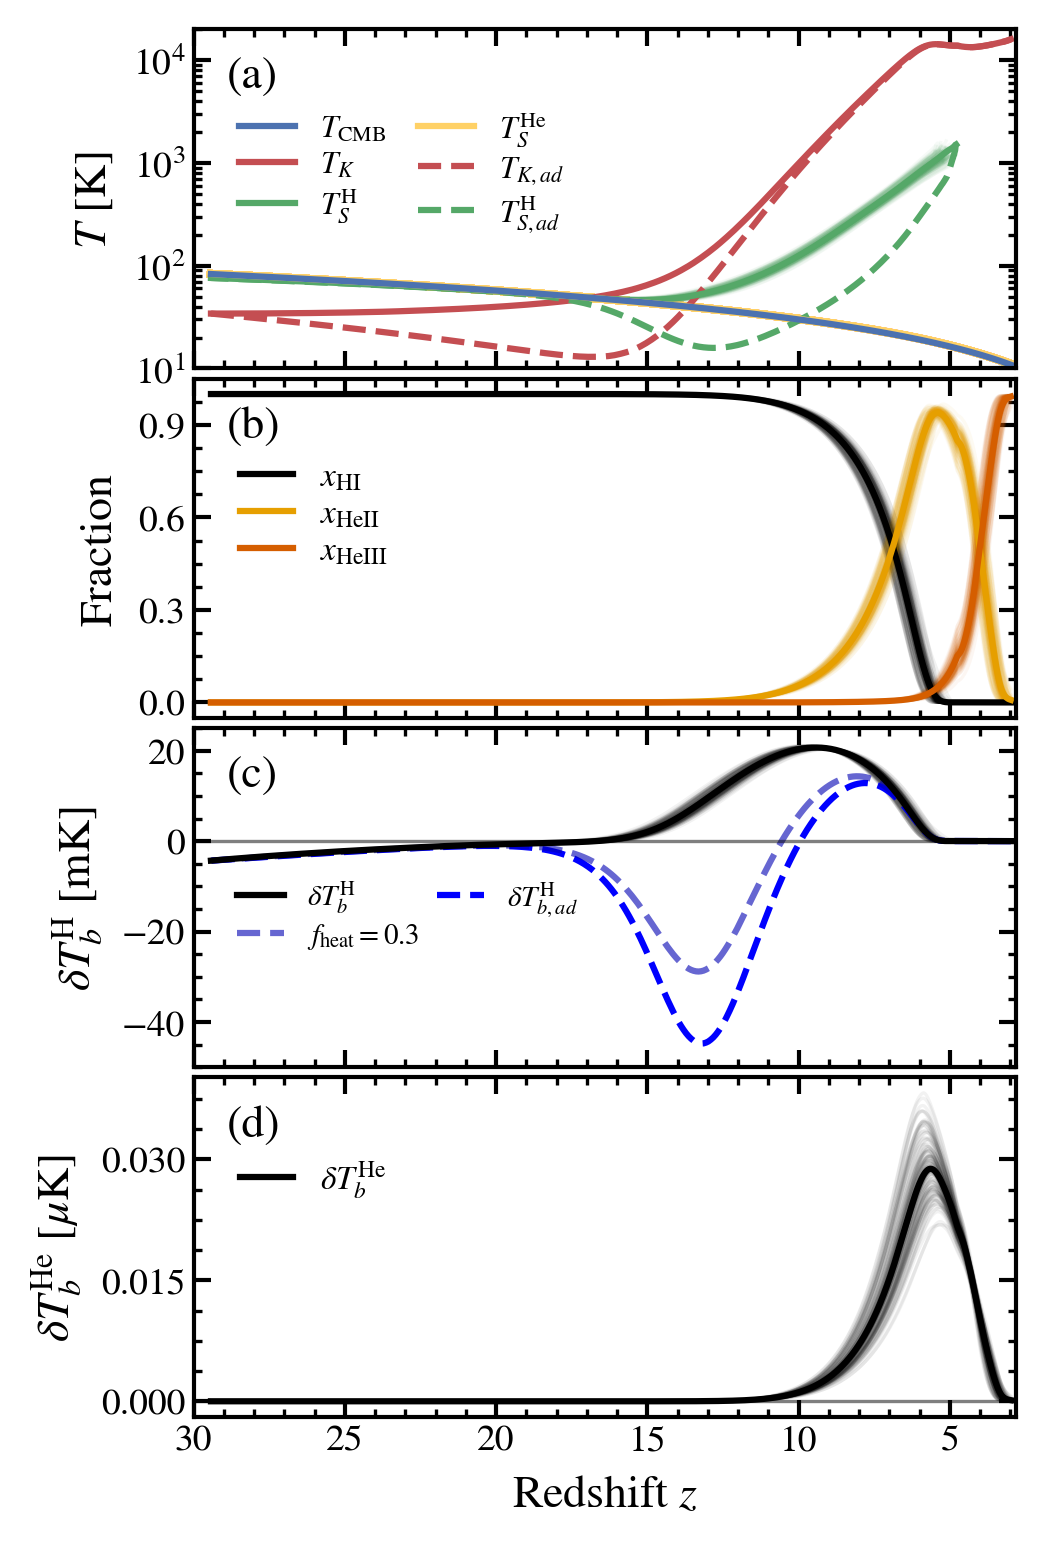

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import LinearSegmentedColormap
from scipy.interpolate import interp1d
# =====================================================
# Publication-quality style
# =====================================================
mpl.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.minor.width": 0.8,
    "ytick.minor.width": 0.8,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "legend.frameon": False,
    "legend.handlelength": 1.7,
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
# =====================================================
# Helper
# =====================================================
def T_CMB(z):
    return 2.725 * (1.0 + z)

def TS_masked(d):
    """T_S, blanked where T_neutral is NaN (no neutral cells left; T_S undefined)."""
    return d["T_S"].where(d["T_neutral"].notna()) if "T_neutral" in d else d["T_S"]
# =====================================================
# Read files
# =====================================================
df_global = pd.read_csv("./LUMINA_ALL.csv") # fiducial model (variable metallicity)
df_xl     = df_global
df_ad     = pd.read_csv("./LUMINA_ALL_ad.csv") # global signals using neutral hydrogen adiabatic temperature (used the ion fraction cut)
df_ad_T   = pd.read_csv("temp_ad.csv") #global T_K_ad (forced adiabatic cooling, only used for showing the T_K,ad plot)
# =====================================================
# Palette
# =====================================================
c_cmb    = "#4C72B0"
c_tk     = "#C44E52"
c_ts     = "#55A868"
c_xHI    = "black"
c_tb     = "black"
c_xHeII  = "#E69F00"
c_xHeIII = "#D55E00"
c_he     = "black"
alpha_local = 0.05
lw_local    = 0.8
lw_global   = 1.5
lw_cmb      = 1.5
# =====================================================
# Figure
# =====================================================
fig, axes = plt.subplots(
    4, 1,
    figsize=(3.45, 5.0),
    sharex=True,
    gridspec_kw={"hspace": 0.03}
)
# =====================================================
# Local cosmic variance realizations
# =====================================================
for x in range(5):
    for y in range(5):
        for z in range(5):
            filename = f"/orcd/data/mvogelsb/004/chcho/global/subvol_125/LUMINA_sub/LUMINA_sub_{x}_{y}_{z}.csv"
            try:
                df = pd.read_csv(filename)
            except:
                continue
            axes[0].plot(df["redshift"], TS_masked(df),
                         color=c_ts, alpha=alpha_local, linewidth=lw_local)
            axes[0].plot(df["redshift"], df["T_S_He"],
                         color="#ffd166", alpha=alpha_local, linewidth=lw_local+1.2)
            axes[1].plot(df["redshift"], df["frac_HI"],
                         color=c_xHI, alpha=alpha_local, linewidth=lw_local)
            axes[1].plot(df["redshift"], df["x_HeII"],
                         color=c_xHeII, alpha=alpha_local, linewidth=lw_local)
            axes[1].plot(df["redshift"], df["x_HeIII"],
                         color=c_xHeIII, alpha=alpha_local, linewidth=lw_local)
            axes[2].plot(df["redshift"], df["T_b"],
                         color=c_tb, alpha=alpha_local, linewidth=lw_local)
            axes[3].plot(df["redshift"], df["T_b_He"],
                         color=c_he, alpha=alpha_local, linewidth=lw_local)
# =====================================================
# Panel (a): Temperature
# =====================================================
ax = axes[0]
ax.plot(df_global["redshift"], df_global["T_vol"],
        color=c_tk, linewidth=lw_global, label=r"$T_K$")
ax.plot(df_ad_T["redshift"], df_ad_T["T_vol"],
        color=c_tk, linestyle="--", linewidth=lw_global, label=r"$T_{K, ad}$")
ax.plot(df_global["redshift"], TS_masked(df_global),
        color=c_ts, linewidth=lw_global, label=r"$T^\mathrm{H}_S$")
ax.plot(df_ad["redshift"], TS_masked(df_ad),
        color=c_ts, linestyle="--", linewidth=lw_global, label=r"$T^\mathrm{H}_{S, ad}$")
ax.plot(df_global["redshift"], df_global["T_S_He"],
        color="#ffd166", linewidth=lw_global, label=r"$T^{\mathrm{He}}_S$")
ax.plot(df_global["redshift"], T_CMB(df_global["redshift"]),
        color=c_cmb, linewidth=lw_cmb, label=r"$T_{\rm CMB}$")
ax.set_ylabel(r"$T\ [{\rm K}]$")
ax.set_yscale("log")
ax.set_ylim(1e1, 2e4)
handles, labels = ax.get_legend_handles_labels()
order = [5, 0, 2, 4, 1, 3]
ax.legend(
    [handles[i] for i in order], [labels[i] for i in order],
    ncol=2, loc="center left", bbox_to_anchor=(0.03, 0.58),
    fontsize=7.5, handlelength=1.8, columnspacing=1.0,
    borderpad=0.15, labelspacing=0.2
)
# =====================================================
# Panel (b): Ionization fractions
# =====================================================
ax = axes[1]
ax.plot(df_global["redshift"], 1.0 - df_global["f_HII"],
        color=c_xHI, linewidth=lw_global, label=r"$x_{\rm HI}$")
ax.plot(df_global["redshift"], df_global["x_HeII"],
        color=c_xHeII, linewidth=lw_global, label=r"$x_{\rm HeII}$")
ax.plot(df_global["redshift"], df_global["x_HeIII"],
        color=c_xHeIII, linewidth=lw_global, label=r"$x_{\rm HeIII}$")
ax.set_ylabel("Fraction")
ax.legend(
    loc="center left", bbox_to_anchor=(0.03, 0.60),
    fontsize=8, handlelength=1.6, borderpad=0.15, labelspacing=0.2
)
# =====================================================
# Panel (c): HI brightness temperature with f_heat mixing
# =====================================================
ax = axes[2]
# Interpolate adiabatic T_b onto global redshift grid
z_common   = df_global["redshift"].values
Tb_full    = df_global["T_b"].values
f_interp   = interp1d(
    df_ad["redshift"].values, df_ad["T_b"].values,
    bounds_error=False, fill_value="extrapolate"
)
Tb_ad_interp = f_interp(z_common)
# f_heat values: 1 = full heating (fiducial), 0 = adiabatic  (f_heat = 1 - f_ad)
f_heat_vals = [0.0, 0.3, 1.0] #0.7, 
f_heat_labels = {
    0.0: r"$\delta T^\mathrm{H}_{b,ad}$",
    1.0: r"$\delta T^\mathrm{H}_b$",
}
f_heat_linestyles = {
    1.0: "-",   # fiducial is the only solid curve
}
f_heat_alphas = {
    0.3: 0.6,
#    0.7: 0.8,
}
cmap_fheat  = LinearSegmentedColormap.from_list("black_blue", ["blue", "black"])
for f in f_heat_vals:
    Tb_mix = (1.0 - f) * Tb_ad_interp + f * Tb_full 
    ax.plot(
        z_common, Tb_mix,
        color=cmap_fheat(f), lw=lw_global,
        linestyle=f_heat_linestyles.get(f, "--"),
        alpha=f_heat_alphas.get(f, 1.0),
        label=f_heat_labels.get(f, r"$f_{\rm heat}=" + f"{f:.1f}$")
    )
ax.axhline(y=0, linestyle="-", color="black", linewidth=0.8, alpha=0.5)
ax.set_ylabel(r"$\delta T_b^{\rm H}\ [{\rm mK}]$")
ax.set_ylim(-50, 25)
# Legend layout (column-major fill with ncol=2):
#   fiducial   0.7
#   0.3        adiabatic
handles, labels = ax.get_legend_handles_labels()
# f_heat_vals draw order is [0.0, 0.3, 0.7, 1.0] -> indices 0,1,2,3
#order = [3, 1, 2, 0]  # fiducial(1.0), 0.3, 0.7, adiabatic(0.0)
order = [2, 1, 0]   # fiducial(1.0), 0.3, adiabatic(0.0)

ax.legend(
    [handles[i] for i in order], [labels[i] for i in order],
    loc="center left", bbox_to_anchor=(0.03, 0.45),
    fontsize=7, handlelength=1.6, borderpad=0.15,
    labelspacing=0.2, ncol=2, columnspacing=0.6
)
# =====================================================
# Panel (d): HeII brightness temperature
# =====================================================
ax = axes[3]
ax.plot(df_global["redshift"], df_global["T_b_He"],
        color=c_he, linewidth=lw_global, label=r"$\delta T_b^{\rm He}$")
ax.axhline(y=0, linestyle="-", color="black", linewidth=0.8, alpha=0.5)
ax.set_ylabel(r"$\delta T_b^{\rm He}\ [\mu{\rm K}]$")
ax.set_xlabel(r"Redshift $z$")
ax.legend(
    loc="center left", bbox_to_anchor=(0.03, 0.70),
    fontsize=8, handlelength=1.6, borderpad=0.15, labelspacing=0.2
)
# =====================================================
# Shared formatting
# =====================================================
for i, ax in enumerate(axes):
    ax.set_xlim(2.8, 30)
    ax.tick_params(which="both", direction="in", top=True, right=True, pad=2)
    ax.minorticks_on()
    if i != 0:
        ax.yaxis.set_major_locator(MaxNLocator(4))
    if i < 3:
        ax.tick_params(labelbottom=False)
axes[-1].invert_xaxis()
# =====================================================
# Panel labels
# =====================================================
for ax, label in zip(axes, ["(a)", "(b)", "(c)", "(d)"]):
    ax.text(0.040, 0.92, label, transform=ax.transAxes,
            fontsize=11, ha="left", va="top")
# =====================================================
# Layout
# =====================================================
fig.subplots_adjust(
    left=0.19, right=0.985,
    bottom=0.07, top=0.995,
    hspace=0.03
)
#plt.savefig(
#    "global_local_variance_fad.pdf",
#    bbox_inches="tight"
#)
#plt.show()

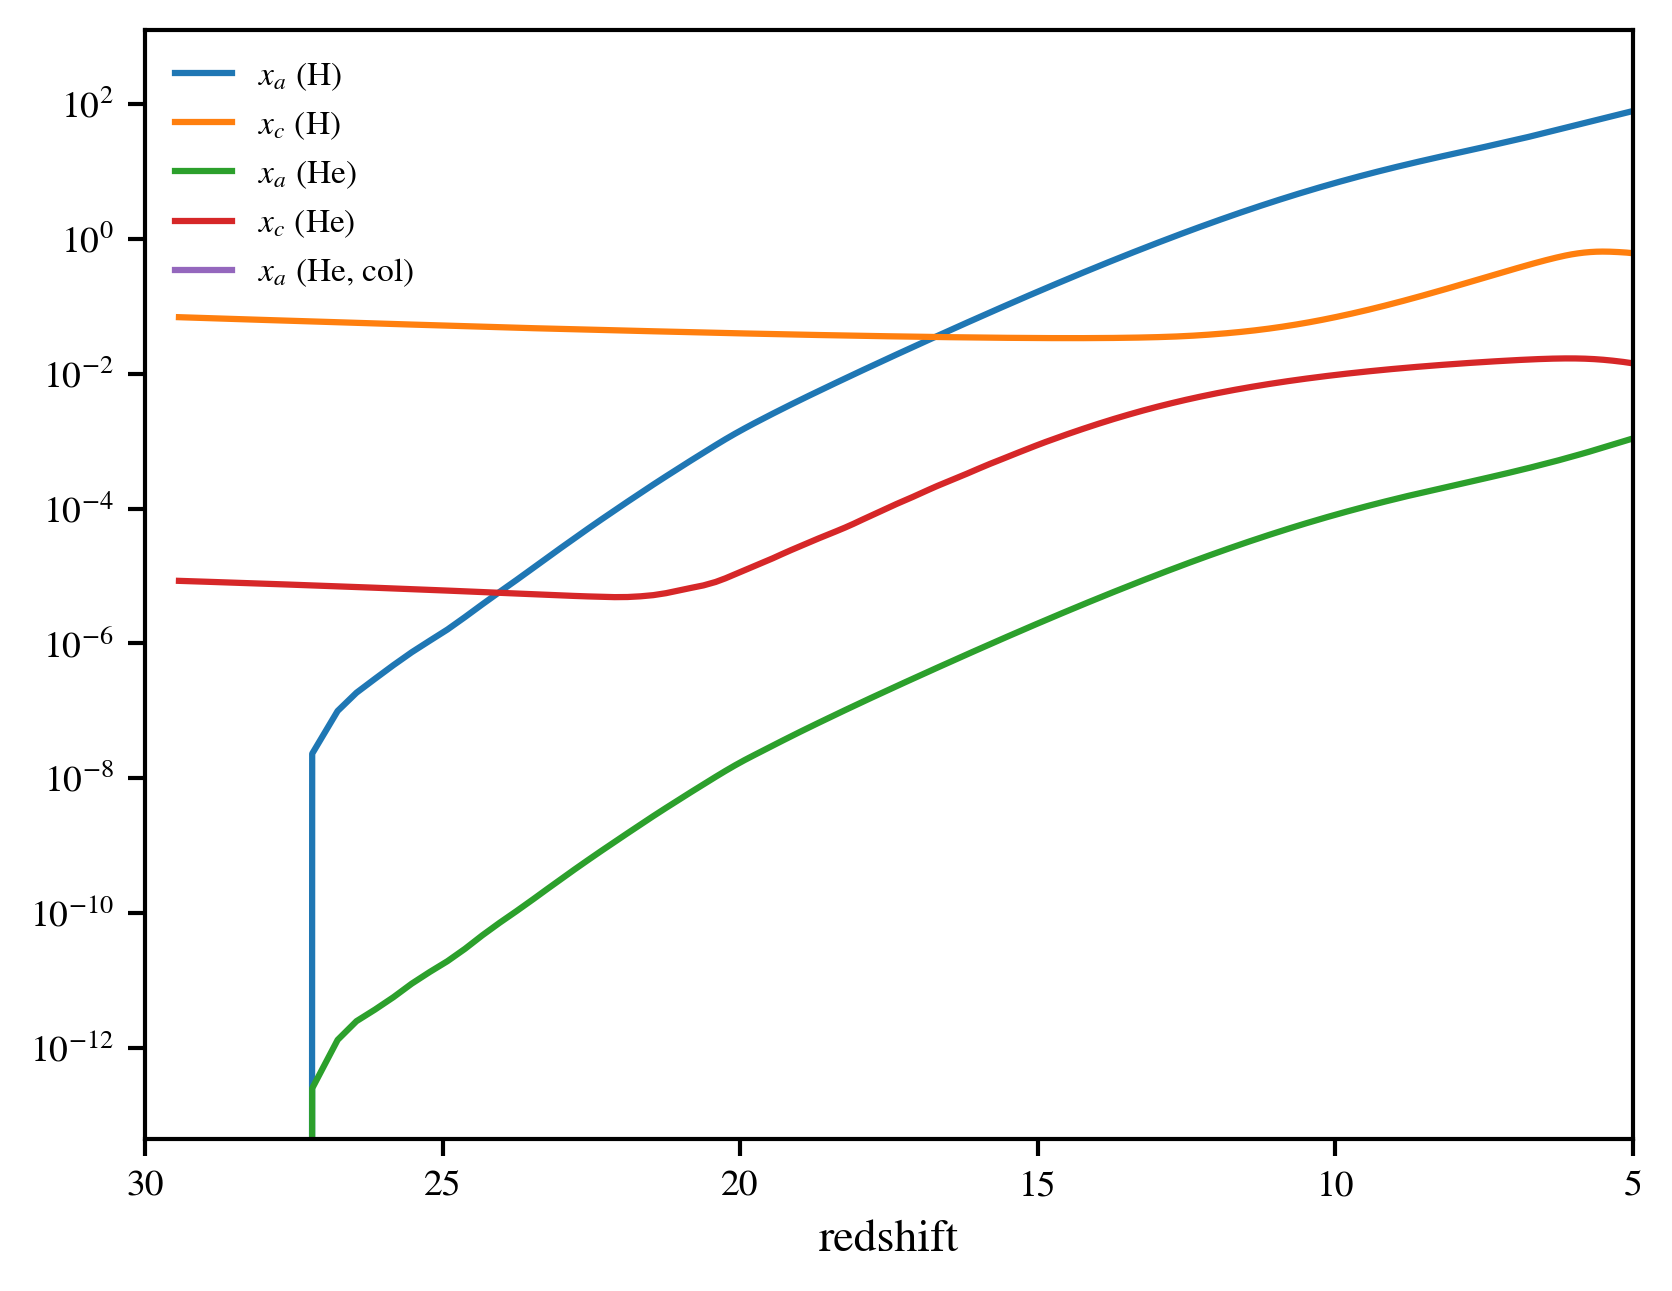

In [9]:

#plt.plot(df["redshift"], df["J_alpha"], label="J_alpha")
plt.plot(df["redshift"], df["x_a"], label=r"$x_a$ (H)")
plt.plot(df["redshift"], df["x_c"], label=r"$x_c$ (H)")
#plt.plot(df["redshift"], df["x_a_X"], label="x_a_X")
plt.plot(df["redshift"], df["x_a_He"], label=r"$x_a$ (He)")
plt.plot(df["redshift"], df["x_c_He"], label=r"$x_c$ (He)")
"J_alpha_star"
#plt.plot(df_col["redshift"], df_col["x_a_He"], label=r"$x_a$ (He, col)")


## To check it, I need to get separted x_a_star, x_a_AGN as well

#plt.plot(z,x_alpha, label="x_a (popIII)")
#plt.plot(df["redshift"], df["num_HI"], label="num_HI")
#plt.plot(df["redshift"], df["num_e"], label="num_e")
#plt.plot(df["redshift"], df["num_p"], label="num_p")
plt.xlabel("redshift")
plt.yscale("log")
plt.legend()
plt.xlim(30, 5)
#plt.ylim(5, 300)
plt.show()

## Metallicity

Files being plotted:
Z = 1.0e-05
Z = 1.0e-04
Z = 1.0e-03
Z = 2.0e-03
Z = 3.0e-03
Z = 4.0e-03
Z = 6.0e-03
Z = 8.0e-03
Z = 1.0e-02
Z = 1.4e-02
Z = 2.0e-02
Z = 3.0e-02
Z = 4.0e-02


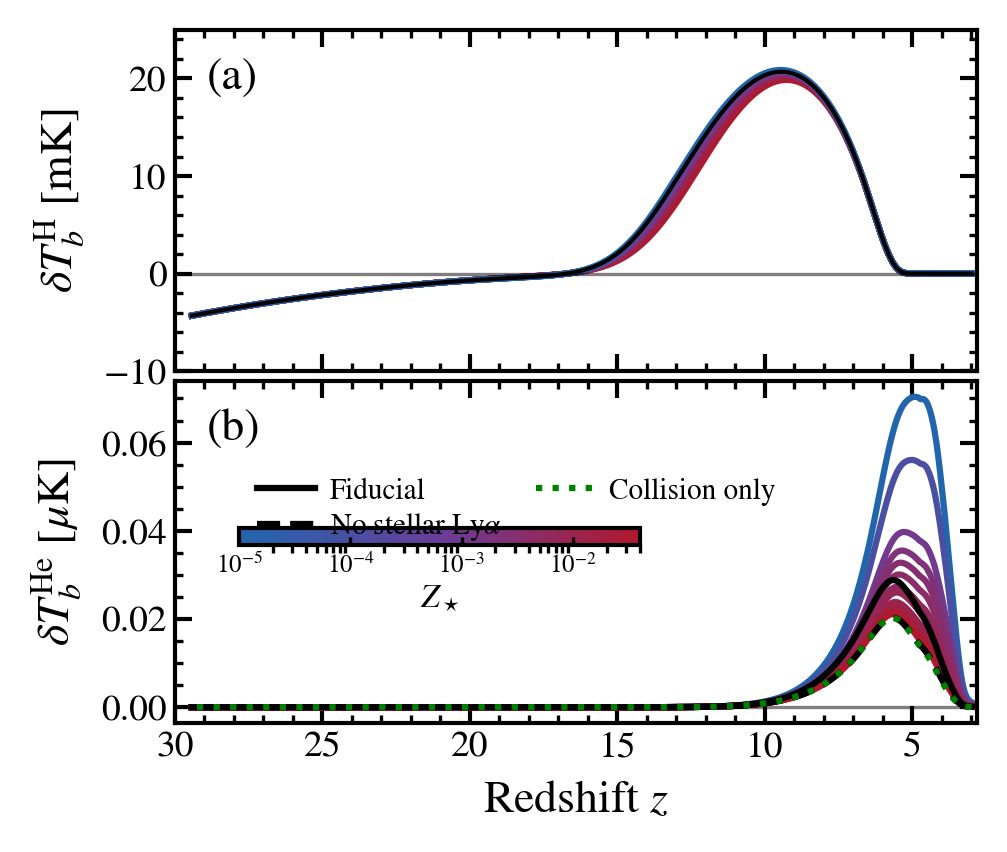

In [10]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from matplotlib.ticker import MaxNLocator
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable


# ============================================================
# Matplotlib settings
# ============================================================

mpl.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.minor.width": 0.8,
    "ytick.minor.width": 0.8,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "legend.frameon": False,
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# ============================================================
# Read all metallicity files
# ============================================================

files = glob.glob("./LUMINA_ALL_Z_*.csv")

files = sorted(
    files,
    key=lambda f: float(
        f.split("LUMINA_ALL_Z_")[1].replace(".csv", "")
    )
)

datasets = []

for filename in files:

    Z = float(
        filename.split("LUMINA_ALL_Z_")[1].replace(".csv", "")
    )

    df = pd.read_csv(filename)

    datasets.append((Z, df))


print("Files being plotted:")
for Z, df in datasets:
    print(f"Z = {Z:.1e}")


# ============================================================
# Read AGN-only contribution
# ============================================================

df_agn = pd.read_csv("only_AGN.csv") # considering AGN + collisional couping
df_fid = pd.read_csv("LUMINA_ALL.csv")      # fiducial run with Z_star(z)
df_col = pd.read_csv("LUMINA_ALL_Coll_only.csv") # considering only collisional coupling

# ============================================================
# Color mapping
# ============================================================

Z_values = np.array([
    Z for Z, df in datasets
])

# Logarithmic normalization because Z spans several orders
# of magnitude.
norm = LogNorm(
    vmin=Z_values.min(),
    vmax=Z_values.max()
)

from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("Z_blue_red", ["#2166ac", "#6a3d9a", "#b2182b"])

colors = cmap(norm(Z_values))


# ============================================================
# Figure
# ============================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(3.45, 3.0),
    sharex=True,
    gridspec_kw={"hspace": 0.03}
)


# ============================================================
# Panel (a): HI brightness temperature
# ============================================================

ax = axes[0]

for (Z, df), color in reversed(list(zip(datasets, colors))):

    ax.plot(
        df["redshift"],
        df["T_b"],
        color=color,
        linewidth=1.5
    )


# Zero line
ax.axhline(
    y=0,
    linestyle="-",
    color="black",
    linewidth=0.8,
    alpha=0.5
)


# Fiducial Z_star(z)
ax.plot(
    df_fid["redshift"],
    df_fid["T_b"],
    color="black",
    linewidth=1
)

ax.set_ylabel(
    r"$\delta T_b^{\rm H}\ [{\rm mK}]$"
)

ax.set_ylim(
    -10,
    25
)


# ============================================================
# Panel (b): He II brightness temperature
# ============================================================

ax = axes[1]

for (Z, df), color in zip(datasets, colors):

    ax.plot(
        df["redshift"],
        df["T_b_He"],
        color=color,
        linewidth=1.5
    )


# Zero line
ax.axhline(
    y=0,
    linestyle="-",
    color="black",
    linewidth=0.8,
    alpha=0.5
)


# ------------------------------------------------------------
# Fiducial Z_star(z)
# ------------------------------------------------------------

ax.plot(
    df_fid["redshift"],
    df_fid["T_b_He"],
    color="black",
    linewidth=1.5,
    label=r"Fiducial"
)


# ------------------------------------------------------------
# AGN+Collisional coupling contribution
# ------------------------------------------------------------

ax.plot(
    df_agn["redshift"],
    df_agn["T_b_He"],
    color="black",
    linewidth=1.5,
    linestyle="--",
    label=r"No stellar Ly$\alpha$" #"AGN only"
)

# ------------------------------------------------------------
# Collisional coupling contribution
# ------------------------------------------------------------


ax.plot(
    df_col["redshift"],
    df_col["T_b_He"],
    color="green",
    linewidth=1.5,
    linestyle=":",
    label=r"Collision only"
)

ax.set_ylabel(
    r"$\delta T_b^{\rm He}\ [\mu{\rm K}]$"
)

ax.set_xlabel(
    r"Redshift $z$"
)


# ============================================================
# Formatting
# ============================================================

for i, ax in enumerate(axes):

    ax.set_xlim(
        2.8,
        30
    )

    ax.tick_params(
        which="both",
        direction="in",
        top=True,
        right=True,
        pad=2
    )

    ax.minorticks_on()

    ax.yaxis.set_major_locator(
        MaxNLocator(4)
    )

    if i < len(axes) - 1:

        ax.tick_params(
            labelbottom=False
        )


# Reverse redshift axis
axes[-1].invert_xaxis()


# ============================================================
# Panel labels
# ============================================================

panel_labels = [
    "(a)",
    "(b)"
]

for ax, label in zip(axes, panel_labels):

    ax.text(
        0.040,
        0.92,
        label,
        transform=ax.transAxes,
        fontsize=11,
        ha="left",
        va="top"
    )


# ============================================================
# AGN-only legend
# ============================================================

axes[1].legend(
    loc="upper left",
    bbox_to_anchor=(0.08, 0.77),
    frameon=False,
    fontsize=7,
    ncol=2,
    columnspacing=1.2,
    handlelength=2.0,
    handletextpad=0.5,
    borderpad=0.1,
    labelspacing=0.2
)


# ============================================================
# Colorbar inside panel (b), upper side
# ============================================================

sm = ScalarMappable(
    norm=norm,
    cmap=cmap
)

sm.set_array([])


# [x0, y0, width, height]
# All values are relative to panel (b).
cax = axes[1].inset_axes(
    [0.08, 0.52, 0.50, 0.05]
)


cbar = plt.colorbar(
    sm,
    cax=cax,
    orientation="horizontal"
)


# Colorbar label
cbar.set_label(
    r"$Z_\star$",
    fontsize=8,
    labelpad=1
)


# Log-spaced metallicity ticks
cbar.set_ticks([
    1e-5,
    1e-4,
    1e-3,
    1e-2
])

cbar.set_ticklabels([
    r"$10^{-5}$",
    r"$10^{-4}$",
    r"$10^{-3}$",
    r"$10^{-2}$"
])


# Colorbar tick formatting
cbar.ax.tick_params(
    direction="in",
    length=2,
    width=0.8,
    pad=2,
    labelsize=6
)


# ============================================================
# Save
# ============================================================

#plt.savefig(
#    "LUMINA_Tb_metallicity.pdf",
#    bbox_inches="tight"
#)


plt.show()

## Check again

1. Collisional only
2. Need to get x_a_star, x_a_AGN to see each contribution


# Previous

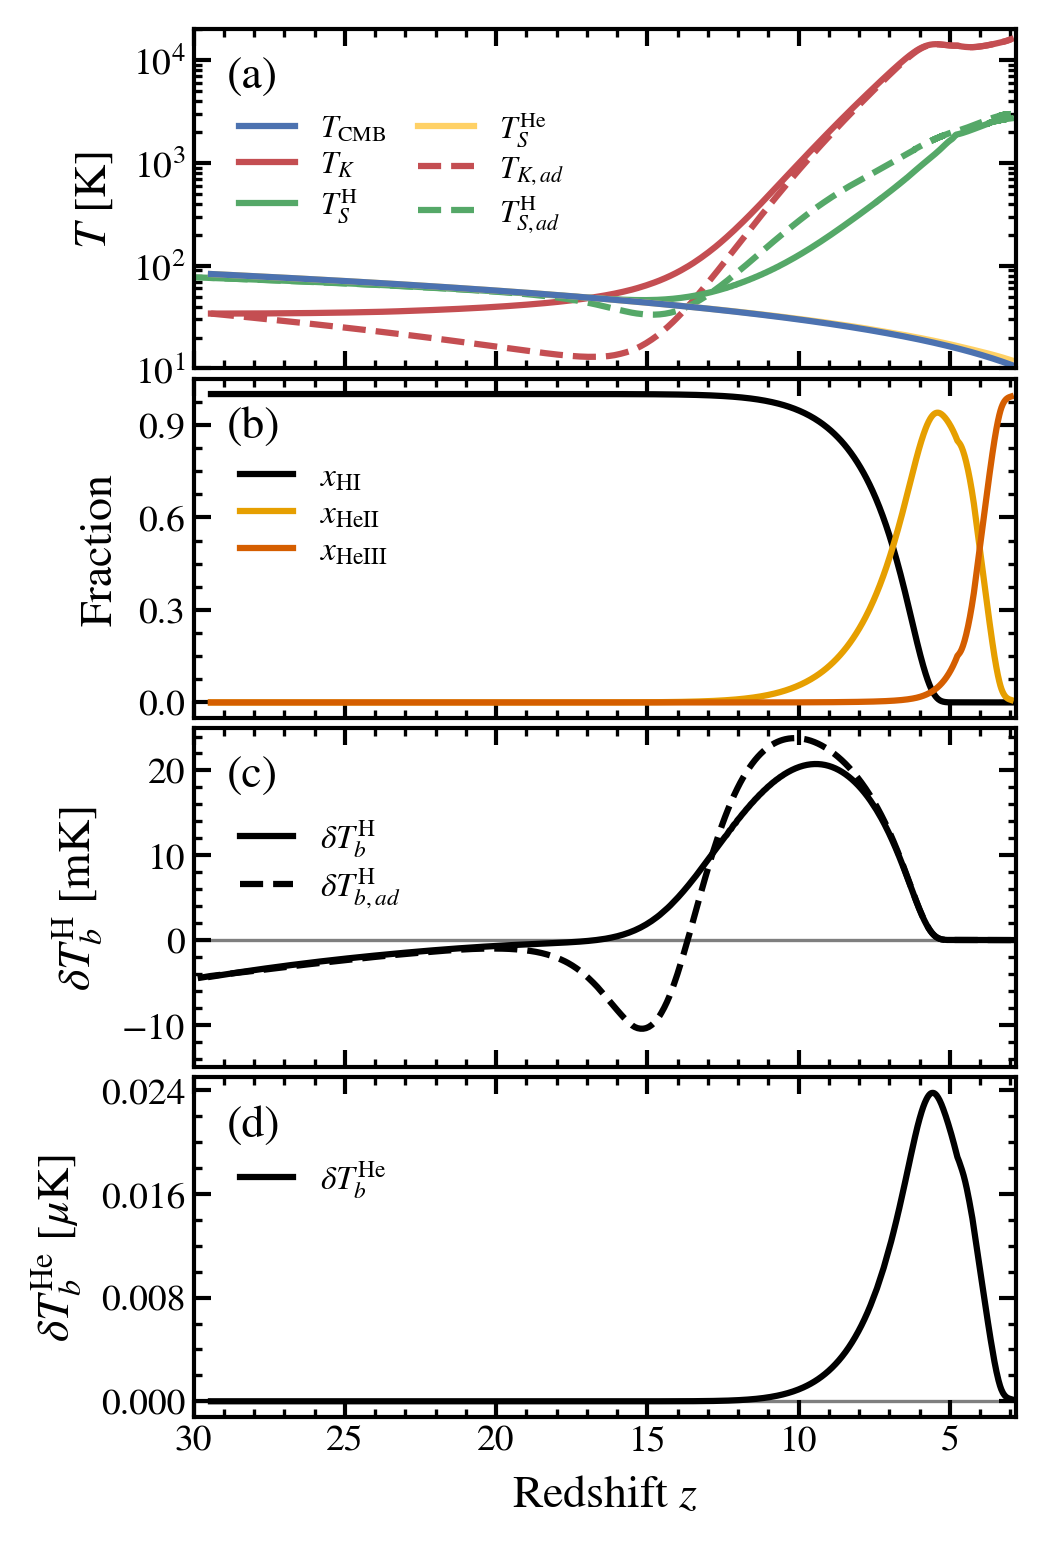

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

# =====================================================
# Publication-quality style
# =====================================================

mpl.rcParams.update({

    # Fonts
    "font.size": 9,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,

    # Axes
    "axes.linewidth": 1.0,

    # Ticks
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.minor.width": 0.8,
    "ytick.minor.width": 0.8,

    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,

    # Legend
    "legend.frameon": False,
    "legend.handlelength": 1.7,

    # Figure
    "figure.dpi": 300,
    "savefig.dpi": 600,

    # Vector fonts
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =====================================================
# Helper
# =====================================================

def T_CMB(z):
    return 2.725 * (1.0 + z)

# =====================================================
# Read files
# =====================================================

df_global = pd.read_csv("./LUMINA_ALL_Z_1.0e-04.csv")
df_xl = df_global
df_helium = pd.read_csv("./LUMINA_ALL_Z_1.0e-02.csv")
df_ad = pd.read_csv("THESAN-XL_ad.csv")
df_ad_T = pd.read_csv("temp_ad.csv")
# =====================================================
# Figure
# =====================================================

fig, axes = plt.subplots(
    4, 1,
    figsize=(3.45, 5.0),
    sharex=True,
    gridspec_kw={"hspace": 0.03}
)

# =====================================================
# Colors
# =====================================================
"""
c_cmb   = "royalblue"
c_tk    = "firebrick"
c_ts    = "forestgreen"

c_xHI   = "purple"
c_tb    = "saddlebrown"

c_xHeII = "teal"
c_he    = "darkorange"
"""
# =====================================================
# Harmonized publication palette
# =====================================================

c_cmb   = "#4C72B0"   # muted blue
c_tk    = "#C44E52"   # muted red
c_ts    = "#55A868"   # muted green

c_xHI   = "black" #"#8172B2"   # muted purple
c_tb    = "black" #"#937860"   # muted brown

c_xHeII  = "#E69F00"   # warm orange
c_xHeIII = "#D55E00"   # darker vermillion
#c_xHeIII = "#004D61"
#c_xHeII = "#4DB6AC"   # muted teal
c_he    = "black" #"#DD8452"   # muted orange
# =====================================================
# Line styles
# =====================================================

alpha_local = 0.05
lw_local = 0.8

lw_global = 1.5
lw_cmb = 1.5

# =====================================================
# Local cosmic variance realizations
# =====================================================
"""
for x in range(5):
    for y in range(5):
        for z in range(5):

            filename = f"./LUMINA_ren5_{x}-{y}-{z}.csv"

            try:
                df = pd.read_csv(filename)
            except:
                continue

            # -----------------------------------------
            # Temperature
            # -----------------------------------------

            axes[0].plot(
                df["redshift"],
                df["T_S"],
                color=c_ts,
                alpha=alpha_local,
                linewidth=lw_local
            )
            axes[0].set_ylim(1e1, 2e4)
            axes[0].set_yscale("log")

            axes[0].plot(
                df["redshift"],
                df["T_S_He"],
                color="#ffd166",
                alpha=alpha_local,
                linewidth=lw_local+1.2
            )
            axes[0].set_ylim(1e1, 2e4)
            axes[0].set_yscale("log")

            # -----------------------------------------
            # xHI
            # -----------------------------------------

            axes[1].plot(
                df["redshift"],
                df["frac_HI"],
                color=c_xHI,
                alpha=alpha_local,
                linewidth=lw_local
            )

            # -----------------------------------------
            # HI signal
            # -----------------------------------------

            axes[2].plot(
                df["redshift"],
                df["T_b"],
                color=c_tb,
                alpha=alpha_local,
                linewidth=lw_local
            )

            # -----------------------------------------
            # xHeII
            # -----------------------------------------

            axes[1].plot(
                df["redshift"],
                df["f_HeII"],
                color=c_xHeII,
                alpha=alpha_local,
                linewidth=lw_local
            )

            axes[1].plot(
                df["redshift"],
                df["num_HeIII"]/df["num_He"],
                color=c_xHeIII,
                alpha=alpha_local,
                #linestyle="-.",
                linewidth=lw_local
            )
            # -----------------------------------------
            # HeII signal
            # -----------------------------------------

            axes[3].plot(
                df["redshift"],
                df["T_b_He"],
                color=c_he,
                alpha=alpha_local,
                linewidth=lw_local
            )
"""
# =====================================================
# Panel (a): Temperature
# =====================================================

ax = axes[0]



ax.plot(
    df_global["redshift"],
    df_global["T_vol"],
    color=c_tk,
    linewidth=lw_global,
    label=r"$T_K$"
)

ax.plot(
    df_ad_T["redshift"],
    df_ad_T["T_vol"],
    color=c_tk,
    linestyle="--",
    linewidth=lw_global,
    label=r"$T_{K, ad}$"
)

ax.plot(
    df_global["redshift"],
    df_global["T_S"],
    color=c_ts,
    linewidth=lw_global,
    label=r"$T^\mathrm{H}_S$"
)

ax.plot(
    df_ad["redshift"],
    df_ad["T_S"],
    color=c_ts,
    linestyle="--",
    linewidth=lw_global,
    label=r"$T^\mathrm{H}_{S, ad}$"
)

ax.plot(
    df_global["redshift"],
    df_global["T_S_He"],
    color="#ffd166",
    linewidth=lw_global,
    label=r"$T^{\mathrm{He}}_S$"
)

ax.plot(
    df_global["redshift"],
    T_CMB(df_global["redshift"]),
    color=c_cmb,
    linewidth=lw_cmb,
    label=r"$T_{\rm CMB}$"
)

ax.set_ylabel(r"$T\ [{\rm K}]$")
ax.set_yscale("log")

# restore original scaling feel
ax.set_ylim(1e1, 2e4)

# -----------------------------------------------------
# Custom 2-column legend
# -----------------------------------------------------

handles, labels = ax.get_legend_handles_labels()

#order = [1, 3, 0, 2, 4, 5]
order = [5, 0, 2, 4, 1, 3]

ax.legend(
    [handles[i] for i in order],
    [labels[i] for i in order],
    ncol=2,
    loc="center left",
    bbox_to_anchor=(0.03, 0.58),
    fontsize=7.5,
    handlelength=1.8,
    columnspacing=1.0,
    borderpad=0.15,
    labelspacing=0.2
)

# =====================================================
# Panel (b): Neutral hydrogen fraction
# =====================================================

ax = axes[1]

ax.plot(
    df_global["redshift"],
    1.0 - df_global["f_HII"],
    color=c_xHI,
    linewidth=lw_global,
    label=r"$x_{\rm HI}$"
)


ax.plot(
    df_global["redshift"],
    df_global["f_HeII"],
    color=c_xHeII,
    linewidth=lw_global,
    label=r"$x_{\rm HeII}$"
)

# HeIII

ax.plot(
    df_global["redshift"],
    df_global["num_HeIII"]/df_global["num_He"],
    color=c_xHeIII,
    linewidth=lw_global,
    #linestyle="-.",
    label=r"$x_{\rm HeIII}$"
)

ax.set_ylabel("Fraction")

ax.legend(
    loc="center left",
    bbox_to_anchor=(0.03, 0.60),
    fontsize=8,
    handlelength=1.6,
    borderpad=0.15,
    labelspacing=0.2
)


"""
ax.legend(
    loc="center left",
    bbox_to_anchor=(0.03, 0.70),
    fontsize=8,
    handlelength=1.6,
    borderpad=0.15,
    labelspacing=0.2
)
"""

# =====================================================
# Panel (c): HI brightness temperature
# =====================================================

ax = axes[2]

ax.plot(
    df_global["redshift"],
    df_global["T_b"],
    color=c_tb,
    linewidth=lw_global,
    label=r"$\delta T_b^{\rm H}$"
)

ax.plot(
    df_ad["redshift"],
    df_ad["T_b"],
    color=c_tb,
    linestyle="--",
    linewidth=lw_global,
    label=r"$\delta T_{b, ad}^{\rm H}$"
)

ax.axhline(
    y=0,
    linestyle="-",
    color="black",
    linewidth=0.8,
    alpha=0.5
)

ax.set_ylabel(r"$\delta T_b^{\rm H}\ [{\rm mK}]$")
ax.set_ylim(-15, 25)

ax.legend(
    loc="center left",
    bbox_to_anchor=(0.03, 0.60),
    fontsize=8,
    handlelength=1.6,
    borderpad=0.15,
    labelspacing=0.2
)

# =====================================================
# Panel (d): HeII fraction
# =====================================================



# =====================================================
# Panel (e): HeII brightness temperature
# =====================================================

ax = axes[3]

ax.plot(
    #df_global["redshift"],
    #df_global["T_b_He"],
    df_helium["redshift"],
    df_helium["T_b_He"],
    color=c_he,
    linewidth=lw_global,
    label=r"$\delta T_b^{\rm He}$"
)

ax.axhline(
    y=0,
    linestyle="-",
    color="black",
    linewidth=0.8,
    alpha=0.5
)

ax.set_ylabel(r"$\delta T_b^{\rm He}\ [\mu{\rm K}]$")

ax.set_xlabel(r"Redshift $z$")

ax.legend(
    loc="center left",
    bbox_to_anchor=(0.03, 0.70),
    fontsize=8,
    handlelength=1.6,
    borderpad=0.15,
    labelspacing=0.2
)

# =====================================================
# Shared formatting
# =====================================================

for i, ax in enumerate(axes):

    ax.set_xlim(2.8, 30)

    ax.tick_params(
        which="both",
        direction="in",
        top=True,
        right=True,
        pad=2
    )

    ax.minorticks_on()

    # consistent tick density
    for i, ax in enumerate(axes):
    
        ax.set_xlim(2.8, 30)
    
        ax.tick_params(
            which="both",
            direction="in",
            top=True,
            right=True,
            pad=2
        )
    
        ax.minorticks_on()
    
        # Only apply MaxNLocator to non-log panels
        if i != 0:
            ax.yaxis.set_major_locator(MaxNLocator(4))
    
        if i < 3:
            ax.tick_params(labelbottom=False)

# invert redshift axis
axes[-1].invert_xaxis()

# =====================================================
# Panel labels
# =====================================================

panel_labels = ["(a)", "(b)", "(c)", "(d)"]

for ax, label in zip(axes, panel_labels):

    ax.text(
        0.040,
        0.92,
        label,
        transform=ax.transAxes,
        fontsize=11,
        ha="left",
        va="top"
    )

# =====================================================
# Layout
# =====================================================

fig.subplots_adjust(
    left=0.19,
    right=0.985,
    bottom=0.07,
    top=0.995,
    hspace=0.03
)

# =====================================================
# Save
# =====================================================

#plt.savefig(
#    "global_local_variance_5panel_singlecolumn.pdf",
#    bbox_inches="tight"
#)

plt.show()

In [4]:
print(df_global.columns.tolist())

['snapshot', 'redshift', 'f_HII', 'f_HeII', 'f_HeIII', 'T_vol', 'T_neutral', 'SFRD', 'Density', 'LuminosityAGN', 'H_cgm', 'H(z)', 'T_CMB', 'rho_H', 'num_H', 'frac_HI', 'num_HI', 'num_HII', 'num_He', 'num_HeII', 'num_HeIII', 'num_HeI', 'num_p', 'num_e', 'J_alpha_AGN', 'J_alpha_AGN_He', 'x_a', 'x_c', 'x_c_He', 'x_a_He', 'J_alpha', 'J_alpha_He', 'T_S', 'T_S_He', 'T_b', 'T_b_He', 'T_b_He_S26', 'T_b_He_K20', 'T_b_He_F08']


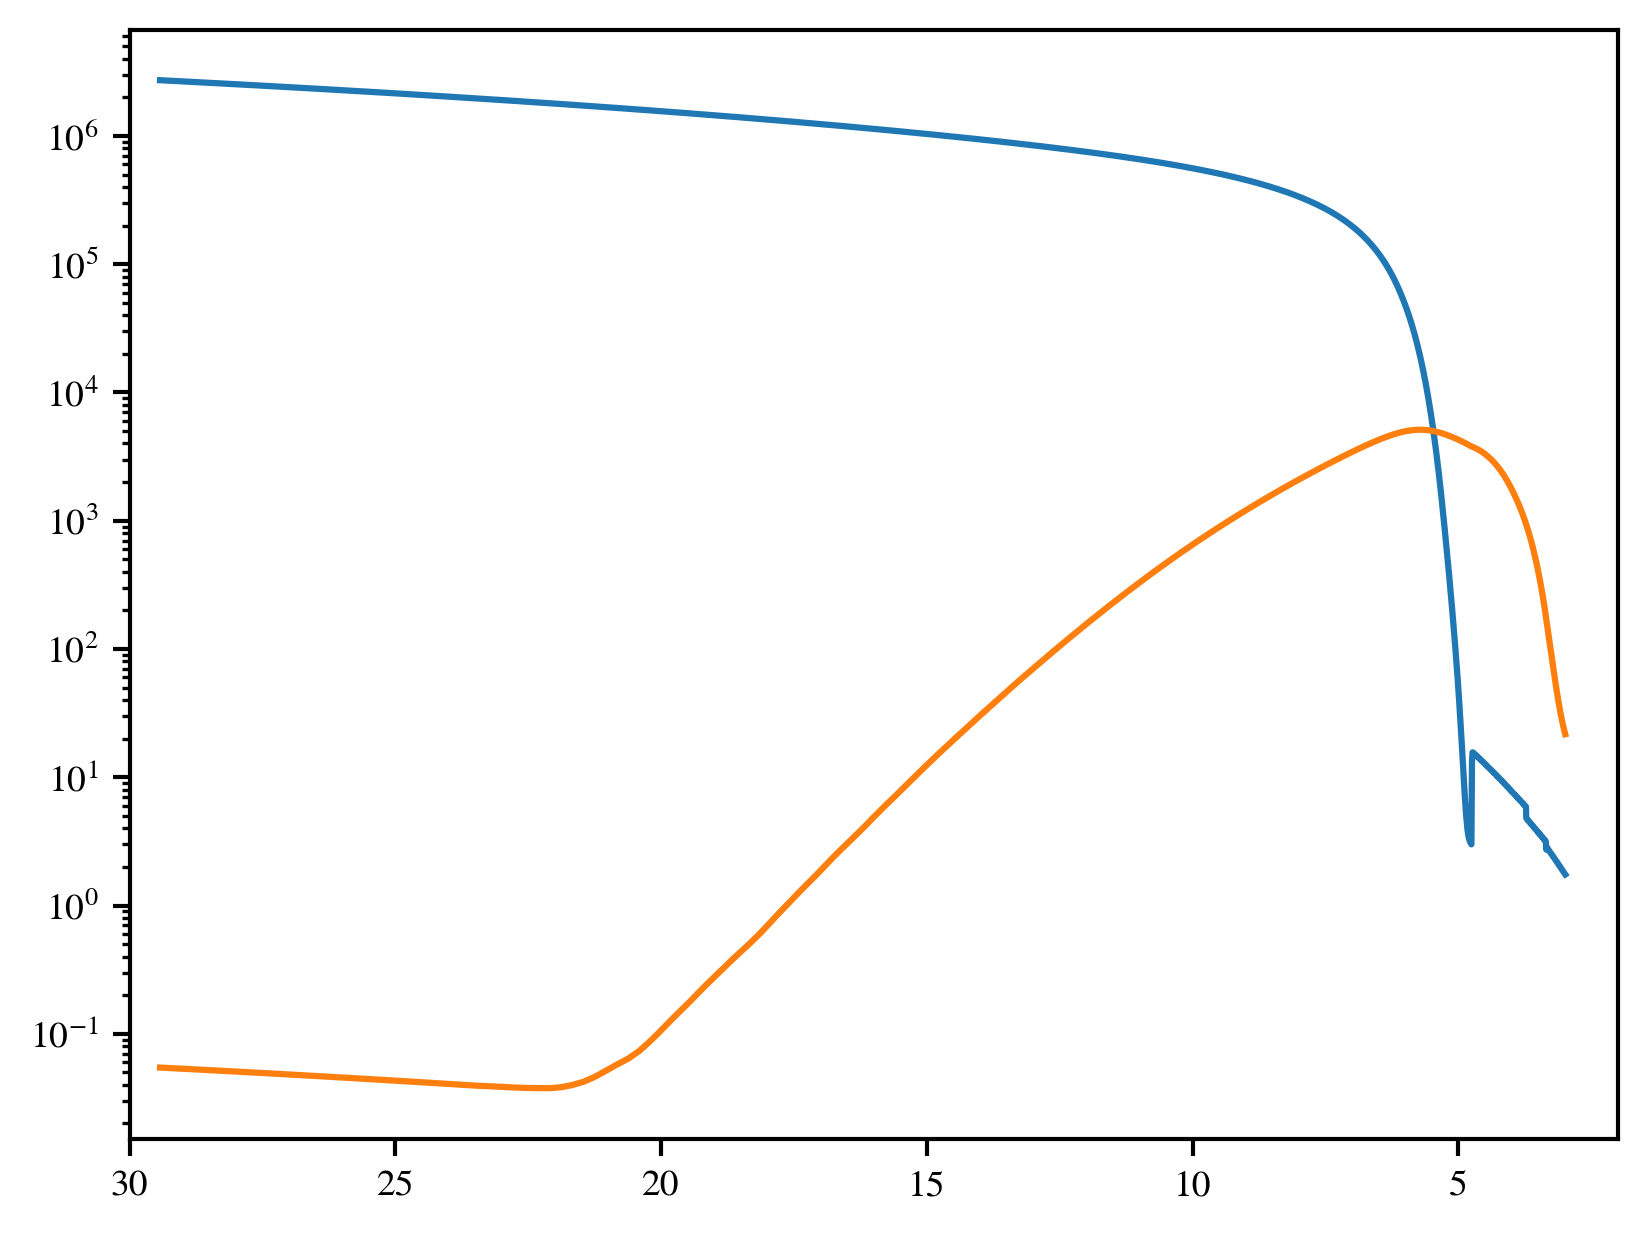

In [25]:
def tau_GP(z):
#Gunn-Peterson optical depth (dimensionless)
    return 3.0e5 * HI_frac(z) * ((1.0+z)/7.0)**1.5


def tau_GP_He(z):
#Gunn-Peterson optical depth (dimensionless)
    return 6.0e3 * HI_frac(z) * ((1.0+z)/7.0)**1.5

plt.plot(df_global["redshift"], 3.0e5 * df_global["frac_HI"] * ((1.0+df_global["redshift"])/7.0)**1.5)
plt.plot(df_global["redshift"], 6.0e3 * df_global["f_HeII"] * ((1.0+df_global["redshift"])/7.0)**1.5)
plt.xlim(30,2)
plt.yscale("log")

(30.0, 2.0)

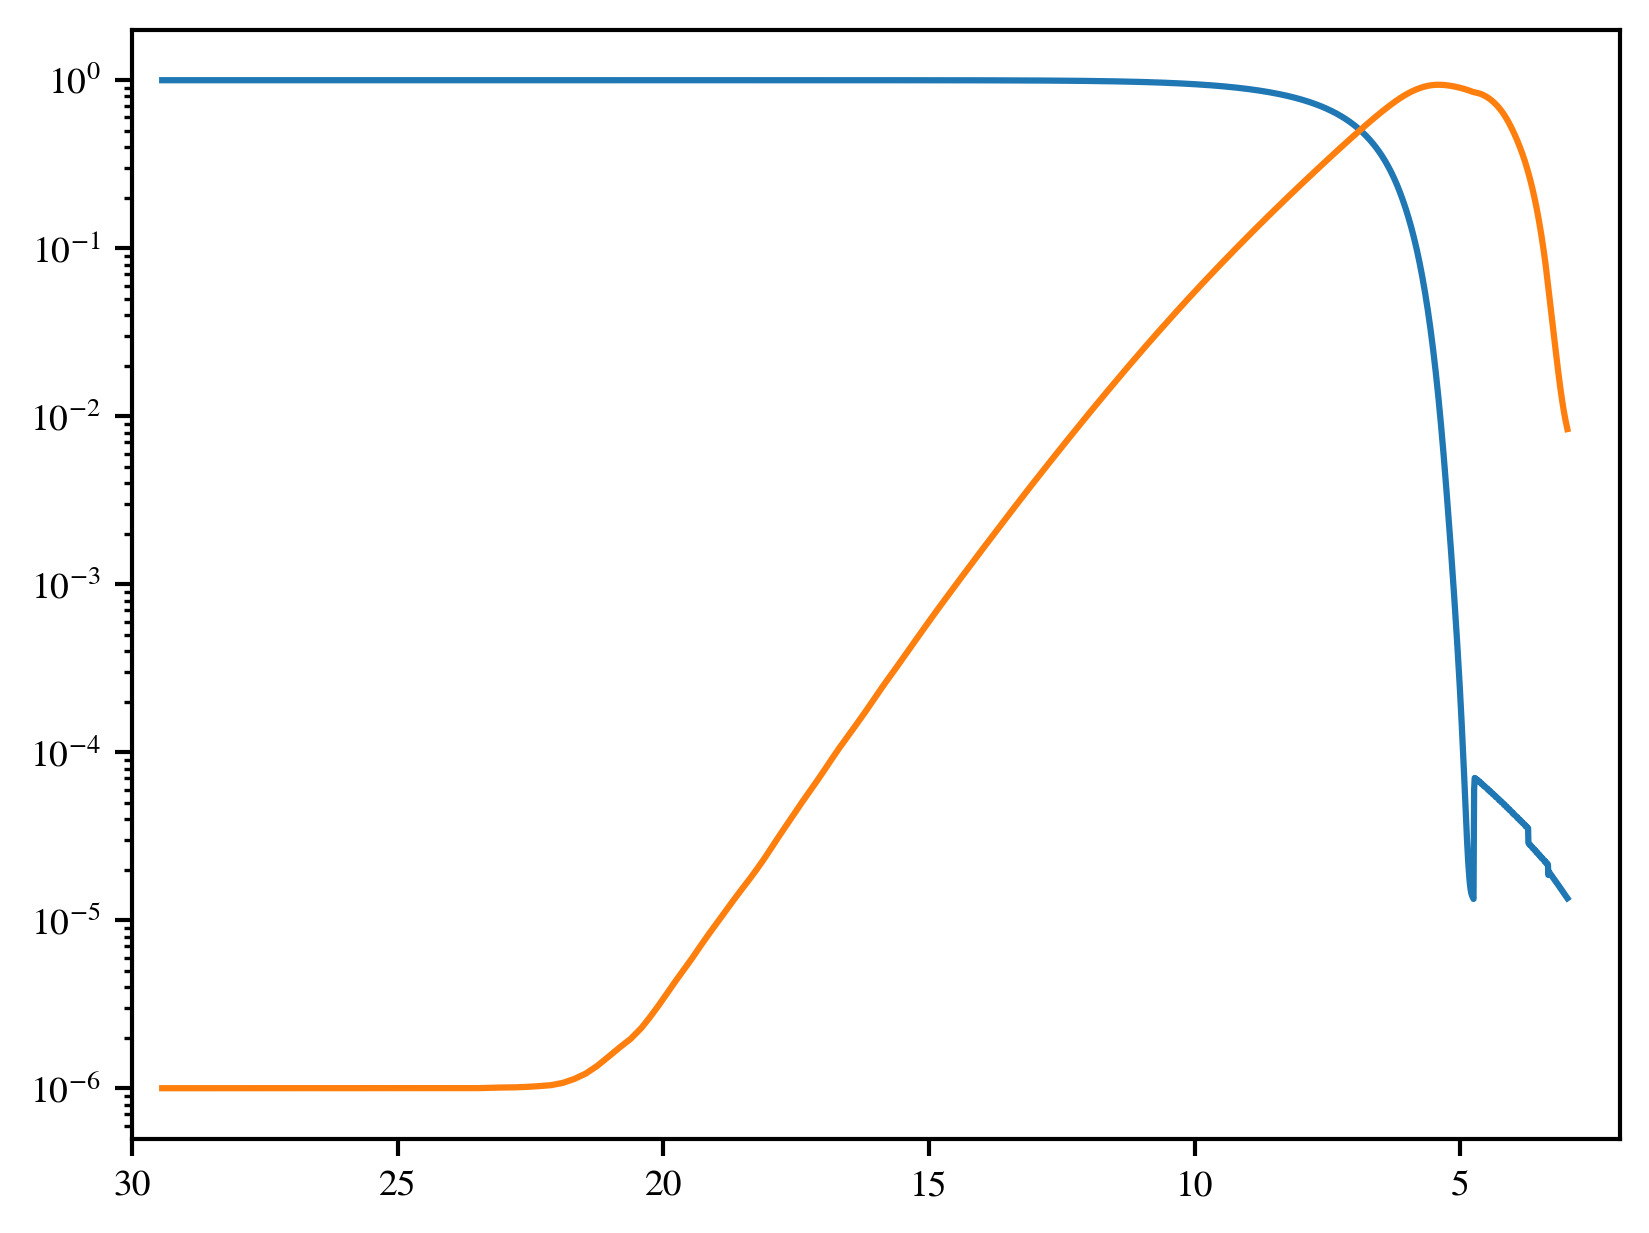

In [24]:
plt.plot(df_global["redshift"], df_global["frac_HI"])
plt.plot(df_global["redshift"],df_global["f_HeII"])
plt.yscale("log")
plt.xlim(30,2)

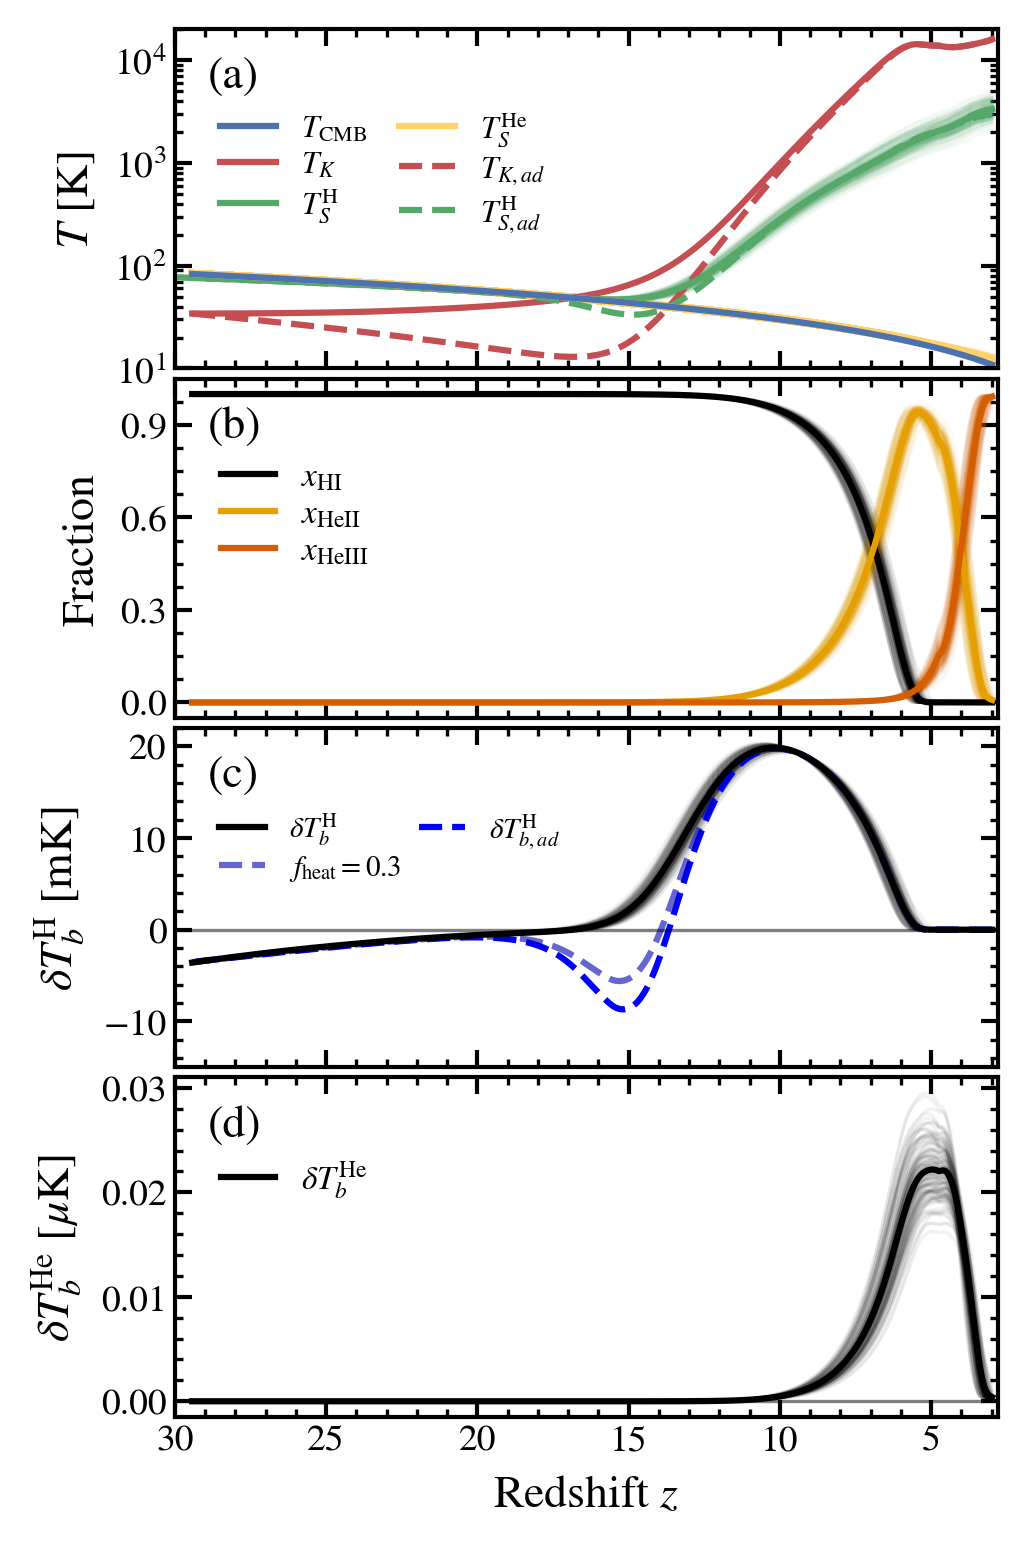

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import LinearSegmentedColormap
from scipy.interpolate import interp1d
# =====================================================
# Publication-quality style
# =====================================================
mpl.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.minor.width": 0.8,
    "ytick.minor.width": 0.8,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "legend.frameon": False,
    "legend.handlelength": 1.7,
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
# =====================================================
# Helper
# =====================================================
def T_CMB(z):
    return 2.725 * (1.0 + z)
# =====================================================
# Read files
# =====================================================
df_global = pd.read_csv("./LUMINA_all.csv")
df_xl     = df_global
df_ad     = pd.read_csv("THESAN-XL_ad.csv")
df_ad_T   = pd.read_csv("temp_ad.csv")
# =====================================================
# Palette
# =====================================================
c_cmb    = "#4C72B0"
c_tk     = "#C44E52"
c_ts     = "#55A868"
c_xHI    = "black"
c_tb     = "black"
c_xHeII  = "#E69F00"
c_xHeIII = "#D55E00"
c_he     = "black"
alpha_local = 0.05
lw_local    = 0.8
lw_global   = 1.5
lw_cmb      = 1.5
# =====================================================
# Figure
# =====================================================
fig, axes = plt.subplots(
    4, 1,
    figsize=(3.45, 5.0),
    sharex=True,
    gridspec_kw={"hspace": 0.03}
)
# =====================================================
# Local cosmic variance realizations
# =====================================================
for x in range(5):
    for y in range(5):
        for z in range(5):
            filename = f"./LUMINA_ren5_{x}-{y}-{z}.csv"
            try:
                df = pd.read_csv(filename)
            except:
                continue
            axes[0].plot(df["redshift"], df["T_S"],
                         color=c_ts, alpha=alpha_local, linewidth=lw_local)
            axes[0].plot(df["redshift"], df["T_S_He"],
                         color="#ffd166", alpha=alpha_local, linewidth=lw_local+1.2)
            axes[1].plot(df["redshift"], df["frac_HI"],
                         color=c_xHI, alpha=alpha_local, linewidth=lw_local)
            axes[1].plot(df["redshift"], df["f_HeII"],
                         color=c_xHeII, alpha=alpha_local, linewidth=lw_local)
            axes[1].plot(df["redshift"], df["num_HeIII"]/df["num_He"],
                         color=c_xHeIII, alpha=alpha_local, linewidth=lw_local)
            axes[2].plot(df["redshift"], df["T_b"],
                         color=c_tb, alpha=alpha_local, linewidth=lw_local)
            axes[3].plot(df["redshift"], df["T_b_He"],
                         color=c_he, alpha=alpha_local, linewidth=lw_local)
# =====================================================
# Panel (a): Temperature
# =====================================================
ax = axes[0]
ax.plot(df_global["redshift"], df_global["T_vol"],
        color=c_tk, linewidth=lw_global, label=r"$T_K$")
ax.plot(df_ad_T["redshift"], df_ad_T["T_vol"],
        color=c_tk, linestyle="--", linewidth=lw_global, label=r"$T_{K, ad}$")
ax.plot(df_global["redshift"], df_global["T_S"],
        color=c_ts, linewidth=lw_global, label=r"$T^\mathrm{H}_S$")
ax.plot(df_ad["redshift"], df_ad["T_S"],
        color=c_ts, linestyle="--", linewidth=lw_global, label=r"$T^\mathrm{H}_{S, ad}$")
ax.plot(df_global["redshift"], df_global["T_S_He"],
        color="#ffd166", linewidth=lw_global, label=r"$T^{\mathrm{He}}_S$")
ax.plot(df_global["redshift"], T_CMB(df_global["redshift"]),
        color=c_cmb, linewidth=lw_cmb, label=r"$T_{\rm CMB}$")
ax.set_ylabel(r"$T\ [{\rm K}]$")
ax.set_yscale("log")
ax.set_ylim(1e1, 2e4)
handles, labels = ax.get_legend_handles_labels()
order = [5, 0, 2, 4, 1, 3]
ax.legend(
    [handles[i] for i in order], [labels[i] for i in order],
    ncol=2, loc="center left", bbox_to_anchor=(0.03, 0.58),
    fontsize=7.5, handlelength=1.8, columnspacing=1.0,
    borderpad=0.15, labelspacing=0.2
)
# =====================================================
# Panel (b): Ionization fractions
# =====================================================
ax = axes[1]
ax.plot(df_global["redshift"], 1.0 - df_global["f_HII"],
        color=c_xHI, linewidth=lw_global, label=r"$x_{\rm HI}$")
ax.plot(df_global["redshift"], df_global["f_HeII"],
        color=c_xHeII, linewidth=lw_global, label=r"$x_{\rm HeII}$")
ax.plot(df_global["redshift"], df_global["num_HeIII"]/df_global["num_He"],
        color=c_xHeIII, linewidth=lw_global, label=r"$x_{\rm HeIII}$")
ax.set_ylabel("Fraction")
ax.legend(
    loc="center left", bbox_to_anchor=(0.03, 0.60),
    fontsize=8, handlelength=1.6, borderpad=0.15, labelspacing=0.2
)
# =====================================================
# Panel (c): HI brightness temperature with f_heat mixing
# =====================================================
ax = axes[2]
# Interpolate adiabatic T_b onto global redshift grid
z_common   = df_global["redshift"].values
Tb_full    = df_global["T_b"].values
f_interp   = interp1d(
    df_ad["redshift"].values, df_ad["T_b"].values,
    bounds_error=False, fill_value="extrapolate"
)
Tb_ad_interp = f_interp(z_common)
# f_heat values: 1 = full heating (fiducial), 0 = adiabatic  (f_heat = 1 - f_ad)
f_heat_vals = [0.0, 0.3, 1.0] #0.7, 
f_heat_labels = {
    0.0: r"$\delta T^\mathrm{H}_{b,ad}$",
    1.0: r"$\delta T^\mathrm{H}_b$",
}
f_heat_linestyles = {
    1.0: "-",   # fiducial is the only solid curve
}
f_heat_alphas = {
    0.3: 0.6,
#    0.7: 0.8,
}
cmap_fheat  = LinearSegmentedColormap.from_list("black_blue", ["blue", "black"])
for f in f_heat_vals:
    Tb_mix = (1.0 - f) * Tb_ad_interp + f * Tb_full 
    ax.plot(
        z_common, Tb_mix,
        color=cmap_fheat(f), lw=lw_global,
        linestyle=f_heat_linestyles.get(f, "--"),
        alpha=f_heat_alphas.get(f, 1.0),
        label=f_heat_labels.get(f, r"$f_{\rm heat}=" + f"{f:.1f}$")
    )
ax.axhline(y=0, linestyle="-", color="black", linewidth=0.8, alpha=0.5)
ax.set_ylabel(r"$\delta T_b^{\rm H}\ [{\rm mK}]$")
ax.set_ylim(-15, 22)
# Legend layout (column-major fill with ncol=2):
#   fiducial   0.7
#   0.3        adiabatic
handles, labels = ax.get_legend_handles_labels()
# f_heat_vals draw order is [0.0, 0.3, 0.7, 1.0] -> indices 0,1,2,3
#order = [3, 1, 2, 0]  # fiducial(1.0), 0.3, 0.7, adiabatic(0.0)
order = [2, 1, 0]   # fiducial(1.0), 0.3, adiabatic(0.0)

ax.legend(
    [handles[i] for i in order], [labels[i] for i in order],
    loc="center left", bbox_to_anchor=(0.03, 0.65),
    fontsize=7, handlelength=1.6, borderpad=0.15,
    labelspacing=0.2, ncol=2, columnspacing=0.6
)
# =====================================================
# Panel (d): HeII brightness temperature
# =====================================================
ax = axes[3]
ax.plot(df_global["redshift"], df_global["T_b_He"],
        color=c_he, linewidth=lw_global, label=r"$\delta T_b^{\rm He}$")
ax.axhline(y=0, linestyle="-", color="black", linewidth=0.8, alpha=0.5)
ax.set_ylabel(r"$\delta T_b^{\rm He}\ [\mu{\rm K}]$")
ax.set_xlabel(r"Redshift $z$")
ax.legend(
    loc="center left", bbox_to_anchor=(0.03, 0.70),
    fontsize=8, handlelength=1.6, borderpad=0.15, labelspacing=0.2
)
# =====================================================
# Shared formatting
# =====================================================
for i, ax in enumerate(axes):
    ax.set_xlim(2.8, 30)
    ax.tick_params(which="both", direction="in", top=True, right=True, pad=2)
    ax.minorticks_on()
    if i != 0:
        ax.yaxis.set_major_locator(MaxNLocator(4))
    if i < 3:
        ax.tick_params(labelbottom=False)
axes[-1].invert_xaxis()
# =====================================================
# Panel labels
# =====================================================
for ax, label in zip(axes, ["(a)", "(b)", "(c)", "(d)"]):
    ax.text(0.040, 0.92, label, transform=ax.transAxes,
            fontsize=11, ha="left", va="top")
# =====================================================
# Layout
# =====================================================
fig.subplots_adjust(
    left=0.19, right=0.985,
    bottom=0.07, top=0.995,
    hspace=0.03
)
plt.savefig(
    "global_local_variance_fad.pdf",
    bbox_inches="tight"
)
#plt.show()



## Metallicity code


Files being plotted:
Z = 1.0e-05
Z = 1.0e-04
Z = 1.0e-03
Z = 2.0e-03
Z = 3.0e-03
Z = 4.0e-03
Z = 6.0e-03
Z = 8.0e-03
Z = 1.0e-02
Z = 1.4e-02
Z = 2.0e-02
Z = 3.0e-02
Z = 4.0e-02


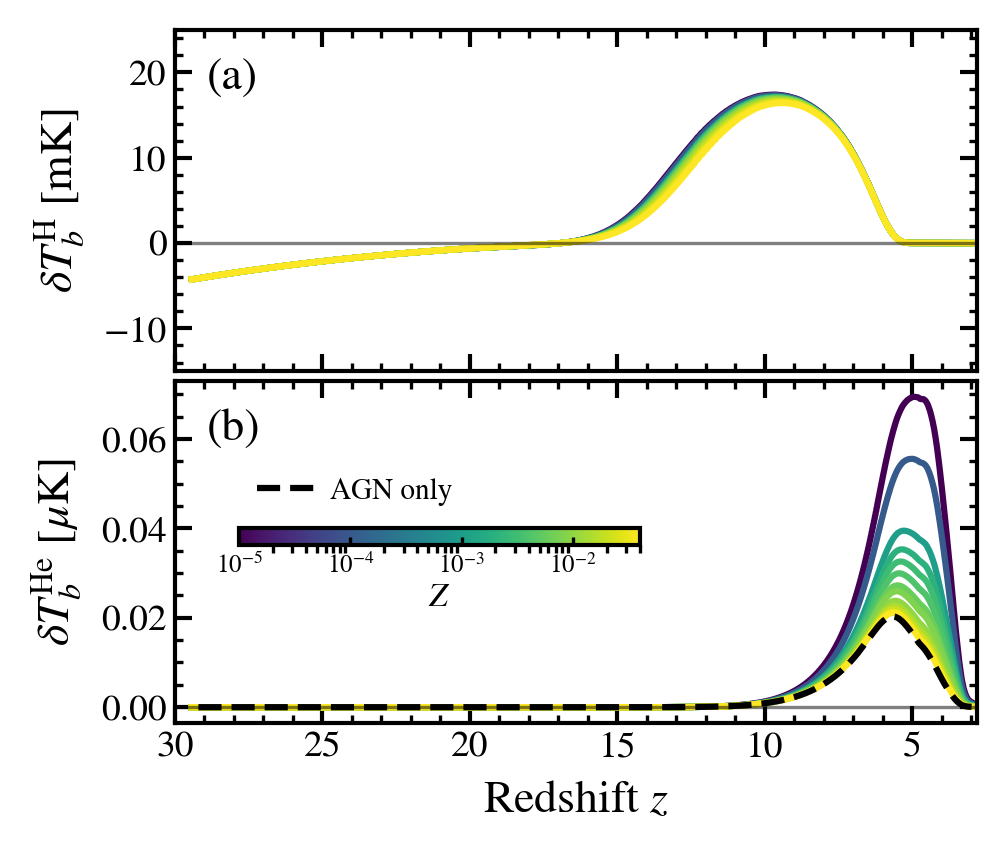

In [8]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from matplotlib.ticker import MaxNLocator
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable


# ============================================================
# Matplotlib settings
# ============================================================

mpl.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.minor.width": 0.8,
    "ytick.minor.width": 0.8,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
    "legend.frameon": False,
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


# ============================================================
# Read all metallicity files
# ============================================================

files = glob.glob("./LUMINA_NoX_Z_*.csv")

files = sorted(
    files,
    key=lambda f: float(
        f.split("LUMINA_NoX_Z_")[1].replace(".csv", "")
    )
)

datasets = []

for filename in files:

    Z = float(
        filename.split("LUMINA_NoX_Z_")[1].replace(".csv", "")
    )

    df = pd.read_csv(filename)

    datasets.append((Z, df))


print("Files being plotted:")
for Z, df in datasets:
    print(f"Z = {Z:.1e}")


# ============================================================
# Read AGN-only contribution
# ============================================================

df_agn = pd.read_csv("only_AGN.csv")


# ============================================================
# Color mapping
# ============================================================

Z_values = np.array([
    Z for Z, df in datasets
])

# Logarithmic normalization because Z spans several orders
# of magnitude.
norm = LogNorm(
    vmin=Z_values.min(),
    vmax=Z_values.max()
)

cmap = plt.cm.viridis

colors = cmap(norm(Z_values))


# ============================================================
# Figure
# ============================================================

fig, axes = plt.subplots(
    2,
    1,
    figsize=(3.45, 3.0),
    sharex=True,
    gridspec_kw={"hspace": 0.03}
)


# ============================================================
# Panel (a): HI brightness temperature
# ============================================================

ax = axes[0]

for (Z, df), color in zip(datasets, colors):

    ax.plot(
        df["redshift"],
        df["T_b"],
        color=color,
        linewidth=1.5
    )


# Zero line
ax.axhline(
    y=0,
    linestyle="-",
    color="black",
    linewidth=0.8,
    alpha=0.5
)


ax.set_ylabel(
    r"$\delta T_b^{\rm H}\ [{\rm mK}]$"
)

ax.set_ylim(
    -15,
    25
)


# ============================================================
# Panel (b): He II brightness temperature
# ============================================================

ax = axes[1]

for (Z, df), color in zip(datasets, colors):

    ax.plot(
        df["redshift"],
        df["T_b_He"],
        color=color,
        linewidth=1.5
    )


# Zero line
ax.axhline(
    y=0,
    linestyle="-",
    color="black",
    linewidth=0.8,
    alpha=0.5
)


# ------------------------------------------------------------
# AGN-only contribution
# ------------------------------------------------------------

ax.plot(
    df_agn["redshift"],
    df_agn["T_b_He"],
    color="black",
    linewidth=1.5,
    linestyle="--",
    label="AGN only"
)


ax.set_ylabel(
    r"$\delta T_b^{\rm He}\ [\mu{\rm K}]$"
)

ax.set_xlabel(
    r"Redshift $z$"
)


# ============================================================
# Formatting
# ============================================================

for i, ax in enumerate(axes):

    ax.set_xlim(
        2.8,
        30
    )

    ax.tick_params(
        which="both",
        direction="in",
        top=True,
        right=True,
        pad=2
    )

    ax.minorticks_on()

    ax.yaxis.set_major_locator(
        MaxNLocator(4)
    )

    if i < len(axes) - 1:

        ax.tick_params(
            labelbottom=False
        )


# Reverse redshift axis
axes[-1].invert_xaxis()


# ============================================================
# Panel labels
# ============================================================

panel_labels = [
    "(a)",
    "(b)"
]

for ax, label in zip(axes, panel_labels):

    ax.text(
        0.040,
        0.92,
        label,
        transform=ax.transAxes,
        fontsize=11,
        ha="left",
        va="top"
    )


# ============================================================
# AGN-only legend
# ============================================================

axes[1].legend(
    loc="upper left",
    bbox_to_anchor=(0.08, 0.77),
    frameon=False,
    fontsize=7,
    handlelength=2.0,
    handletextpad=0.5,
    borderpad=0.1,
    labelspacing=0.2
)


# ============================================================
# Colorbar inside panel (b), upper side
# ============================================================

sm = ScalarMappable(
    norm=norm,
    cmap=cmap
)

sm.set_array([])


# [x0, y0, width, height]
# All values are relative to panel (b).
cax = axes[1].inset_axes(
    [0.08, 0.52, 0.50, 0.05]
)


cbar = plt.colorbar(
    sm,
    cax=cax,
    orientation="horizontal"
)


# Colorbar label
cbar.set_label(
    r"$Z$",
    fontsize=8,
    labelpad=1
)


# Log-spaced metallicity ticks
cbar.set_ticks([
    1e-5,
    1e-4,
    1e-3,
    1e-2
])

cbar.set_ticklabels([
    r"$10^{-5}$",
    r"$10^{-4}$",
    r"$10^{-3}$",
    r"$10^{-2}$"
])


# Colorbar tick formatting
cbar.ax.tick_params(
    direction="in",
    length=2,
    width=0.8,
    pad=2,
    labelsize=6
)


# ============================================================
# Save
# ============================================================

#plt.savefig(
#    "LUMINA_Tb_metallicity.pdf",
#    bbox_inches="tight"
#)


plt.show()

## Previous Code

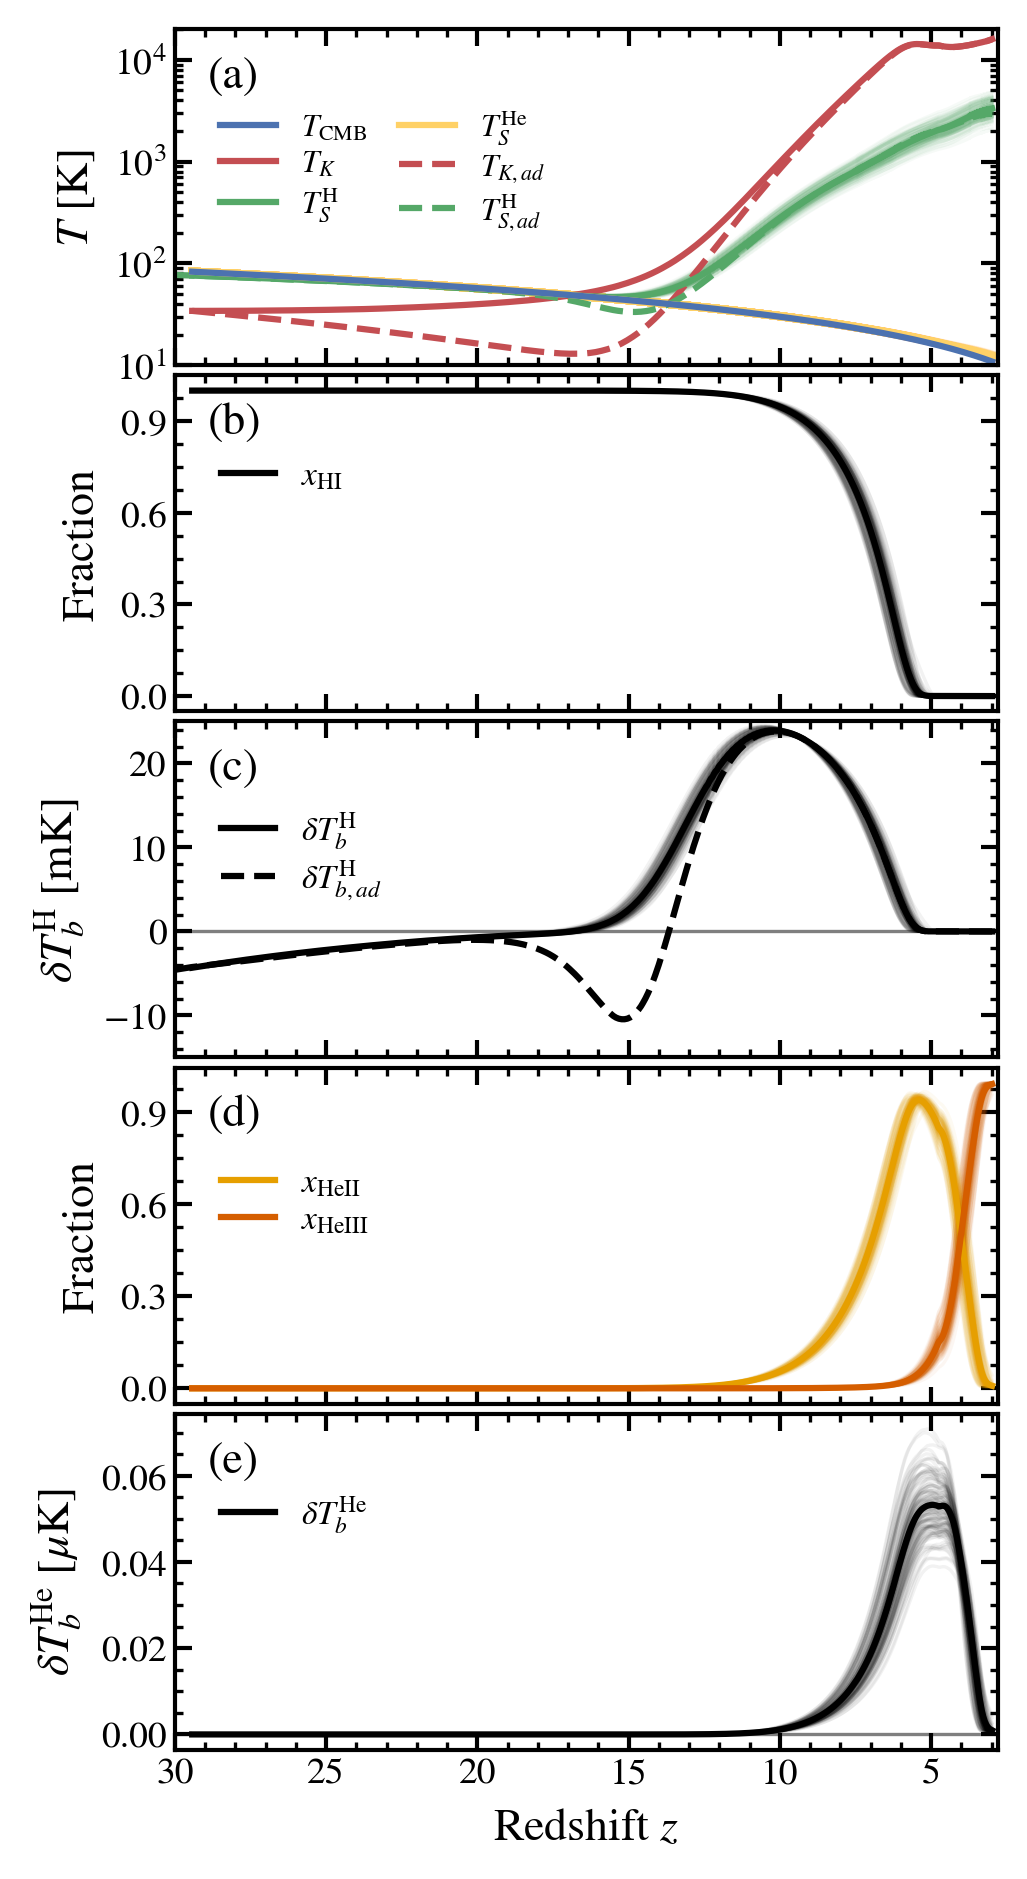

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

# =====================================================
# Publication-quality style
# =====================================================

mpl.rcParams.update({

    # Fonts
    "font.size": 9,
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,

    # Axes
    "axes.linewidth": 1.0,

    # Ticks
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.minor.width": 0.8,
    "ytick.minor.width": 0.8,

    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,

    # Legend
    "legend.frameon": False,
    "legend.handlelength": 1.7,

    # Figure
    "figure.dpi": 300,
    "savefig.dpi": 600,

    # Vector fonts
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# =====================================================
# Helper
# =====================================================

def T_CMB(z):
    return 2.725 * (1.0 + z)

# =====================================================
# Read files
# =====================================================

df_global = pd.read_csv("./LUMINA_all.csv")
df_xl = df_global
df_ad = pd.read_csv("THESAN-XL_ad.csv")
df_ad_T = pd.read_csv("temp_ad.csv")
# =====================================================
# Figure
# =====================================================

fig, axes = plt.subplots(
    5, 1,
    figsize=(3.45, 6.2),
    sharex=True,
    gridspec_kw={"hspace": 0.03}
)

# =====================================================
# Colors
# =====================================================
"""
c_cmb   = "royalblue"
c_tk    = "firebrick"
c_ts    = "forestgreen"

c_xHI   = "purple"
c_tb    = "saddlebrown"

c_xHeII = "teal"
c_he    = "darkorange"
"""
# =====================================================
# Harmonized publication palette
# =====================================================

c_cmb   = "#4C72B0"   # muted blue
c_tk    = "#C44E52"   # muted red
c_ts    = "#55A868"   # muted green

c_xHI   = "black" #"#8172B2"   # muted purple
c_tb    = "black" #"#937860"   # muted brown

c_xHeII  = "#E69F00"   # warm orange
c_xHeIII = "#D55E00"   # darker vermillion
#c_xHeIII = "#004D61"
#c_xHeII = "#4DB6AC"   # muted teal
c_he    = "black" #"#DD8452"   # muted orange
# =====================================================
# Line styles
# =====================================================

alpha_local = 0.05
lw_local = 0.8

lw_global = 1.5
lw_cmb = 1.5

# =====================================================
# Local cosmic variance realizations
# =====================================================

for x in range(5):
    for y in range(5):
        for z in range(5):

            filename = f"./LUMINA_ren5_{x}-{y}-{z}.csv"

            try:
                df = pd.read_csv(filename)
            except:
                continue

            # -----------------------------------------
            # Temperature
            # -----------------------------------------

            axes[0].plot(
                df["redshift"],
                df["T_S"],
                color=c_ts,
                alpha=alpha_local,
                linewidth=lw_local
            )
            axes[0].set_ylim(1e1, 2e4)
            axes[0].set_yscale("log")

            axes[0].plot(
                df["redshift"],
                df["T_S_He"],
                color="#ffd166",
                alpha=alpha_local,
                linewidth=lw_local+1.2
            )
            axes[0].set_ylim(1e1, 2e4)
            axes[0].set_yscale("log")

            # -----------------------------------------
            # xHI
            # -----------------------------------------

            axes[1].plot(
                df["redshift"],
                df["frac_HI"],
                color=c_xHI,
                alpha=alpha_local,
                linewidth=lw_local
            )

            # -----------------------------------------
            # HI signal
            # -----------------------------------------

            axes[2].plot(
                df["redshift"],
                df["T_b"],
                color=c_tb,
                alpha=alpha_local,
                linewidth=lw_local
            )

            # -----------------------------------------
            # xHeII
            # -----------------------------------------

            axes[3].plot(
                df["redshift"],
                df["f_HeII"],
                color=c_xHeII,
                alpha=alpha_local,
                linewidth=lw_local
            )

            axes[3].plot(
                df["redshift"],
                df["num_HeIII"]/df["num_He"],
                color=c_xHeIII,
                alpha=alpha_local,
                #linestyle="-.",
                linewidth=lw_local
            )
            # -----------------------------------------
            # HeII signal
            # -----------------------------------------

            axes[4].plot(
                df["redshift"],
                df["T_b_He"],
                color=c_he,
                alpha=alpha_local,
                linewidth=lw_local
            )

# =====================================================
# Panel (a): Temperature
# =====================================================

ax = axes[0]



ax.plot(
    df_global["redshift"],
    df_global["T_vol"],
    color=c_tk,
    linewidth=lw_global,
    label=r"$T_K$"
)

ax.plot(
    df_ad_T["redshift"],
    df_ad_T["T_vol"],
    color=c_tk,
    linestyle="--",
    linewidth=lw_global,
    label=r"$T_{K, ad}$"
)

ax.plot(
    df_global["redshift"],
    df_global["T_S"],
    color=c_ts,
    linewidth=lw_global,
    label=r"$T^\mathrm{H}_S$"
)

ax.plot(
    df_ad["redshift"],
    df_ad["T_S"],
    color=c_ts,
    linestyle="--",
    linewidth=lw_global,
    label=r"$T^\mathrm{H}_{S, ad}$"
)

ax.plot(
    df_global["redshift"],
    df_global["T_S_He"],
    color="#ffd166",
    linewidth=lw_global,
    label=r"$T^{\mathrm{He}}_S$"
)

ax.plot(
    df_global["redshift"],
    T_CMB(df_global["redshift"]),
    color=c_cmb,
    linewidth=lw_cmb,
    label=r"$T_{\rm CMB}$"
)

ax.set_ylabel(r"$T\ [{\rm K}]$")
ax.set_yscale("log")

# restore original scaling feel
ax.set_ylim(1e1, 2e4)

# -----------------------------------------------------
# Custom 2-column legend
# -----------------------------------------------------

handles, labels = ax.get_legend_handles_labels()

#order = [1, 3, 0, 2, 4, 5]
order = [5, 0, 2, 4, 1, 3]

ax.legend(
    [handles[i] for i in order],
    [labels[i] for i in order],
    ncol=2,
    loc="center left",
    bbox_to_anchor=(0.03, 0.58),
    fontsize=7.5,
    handlelength=1.8,
    columnspacing=1.0,
    borderpad=0.15,
    labelspacing=0.2
)

# =====================================================
# Panel (b): Neutral hydrogen fraction
# =====================================================

ax = axes[1]

ax.plot(
    df_global["redshift"],
    1.0 - df_global["f_HII"],
    color=c_xHI,
    linewidth=lw_global,
    label=r"$x_{\rm HI}$"
)

ax.set_ylabel("Fraction")

ax.legend(
    loc="center left",
    bbox_to_anchor=(0.03, 0.70),
    fontsize=8,
    handlelength=1.6,
    borderpad=0.15,
    labelspacing=0.2
)

# =====================================================
# Panel (c): HI brightness temperature
# =====================================================

ax = axes[2]

ax.plot(
    df_global["redshift"],
    df_global["T_b"],
    color=c_tb,
    linewidth=lw_global,
    label=r"$\delta T_b^{\rm H}$"
)

ax.plot(
    df_ad["redshift"],
    df_ad["T_b"],
    color=c_tb,
    linestyle="--",
    linewidth=lw_global,
    label=r"$\delta T_{b, ad}^{\rm H}$"
)

ax.axhline(
    y=0,
    linestyle="-",
    color="black",
    linewidth=0.8,
    alpha=0.5
)

ax.set_ylabel(r"$\delta T_b^{\rm H}\ [{\rm mK}]$")
ax.set_ylim(-15, 25)

ax.legend(
    loc="center left",
    bbox_to_anchor=(0.03, 0.60),
    fontsize=8,
    handlelength=1.6,
    borderpad=0.15,
    labelspacing=0.2
)

# =====================================================
# Panel (d): HeII fraction
# =====================================================

ax = axes[3]

ax.plot(
    df_global["redshift"],
    df_global["f_HeII"],
    color=c_xHeII,
    linewidth=lw_global,
    label=r"$x_{\rm HeII}$"
)

# HeIII

ax.plot(
    df_global["redshift"],
    df_global["num_HeIII"]/df_global["num_He"],
    color=c_xHeIII,
    linewidth=lw_global,
    #linestyle="-.",
    label=r"$x_{\rm HeIII}$"
)

ax.set_ylabel("Fraction")

ax.legend(
    loc="center left",
    bbox_to_anchor=(0.03, 0.60),
    fontsize=8,
    handlelength=1.6,
    borderpad=0.15,
    labelspacing=0.2
)

# =====================================================
# Panel (e): HeII brightness temperature
# =====================================================

ax = axes[4]

ax.plot(
    df_global["redshift"],
    df_global["T_b_He"],
    color=c_he,
    linewidth=lw_global,
    label=r"$\delta T_b^{\rm He}$"
)

ax.axhline(
    y=0,
    linestyle="-",
    color="black",
    linewidth=0.8,
    alpha=0.5
)

ax.set_ylabel(r"$\delta T_b^{\rm He}\ [\mu{\rm K}]$")

ax.set_xlabel(r"Redshift $z$")

ax.legend(
    loc="center left",
    bbox_to_anchor=(0.03, 0.70),
    fontsize=8,
    handlelength=1.6,
    borderpad=0.15,
    labelspacing=0.2
)

# =====================================================
# Shared formatting
# =====================================================

for i, ax in enumerate(axes):

    ax.set_xlim(2.8, 30)

    ax.tick_params(
        which="both",
        direction="in",
        top=True,
        right=True,
        pad=2
    )

    ax.minorticks_on()

    # consistent tick density
    for i, ax in enumerate(axes):
    
        ax.set_xlim(2.8, 30)
    
        ax.tick_params(
            which="both",
            direction="in",
            top=True,
            right=True,
            pad=2
        )
    
        ax.minorticks_on()
    
        # Only apply MaxNLocator to non-log panels
        if i != 0:
            ax.yaxis.set_major_locator(MaxNLocator(4))
    
        if i < 4:
            ax.tick_params(labelbottom=False)

# invert redshift axis
axes[-1].invert_xaxis()

# =====================================================
# Panel labels
# =====================================================

panel_labels = ["(a)", "(b)", "(c)", "(d)", "(e)"]

for ax, label in zip(axes, panel_labels):

    ax.text(
        0.040,
        0.92,
        label,
        transform=ax.transAxes,
        fontsize=11,
        ha="left",
        va="top"
    )

# =====================================================
# Layout
# =====================================================

fig.subplots_adjust(
    left=0.19,
    right=0.985,
    bottom=0.07,
    top=0.995,
    hspace=0.03
)

# =====================================================
# Save
# =====================================================

#plt.savefig(
#    "global_local_variance_5panel_singlecolumn.pdf",
#    bbox_inches="tight"
#)

plt.show()

In [22]:
import pandas as pd
import os

# Set the anomaly threshold
THRESHOLD = 0.9

print(f"Scanning files for T_b_He >= {THRESHOLD}...\n")
anomaly_count = 0

# Loop through the 3D grid of cosmic variance realizations
for x in range(5):
    for y in range(5):
        for z in range(5):
            filename = f"./LUMINA_ren5_{x}-{y}-{z}.csv"
            
            # Skip quietly if a specific realization file doesn't exist
            if not os.path.exists(filename):
                continue
                
            try:
                df = pd.read_csv(filename)
                
                if "T_b_He" in df.columns:
                    max_tb_he = df["T_b_He"].max()
                    
                    # Check if this file contains the anomaly
                    if max_tb_he >= THRESHOLD:
                        anomaly_count += 1
                        
                        # Pinpoint the exact row and redshift where the spike occurs
                        peak_row_idx = df["T_b_He"].idxmax()
                        peak_redshift = df.loc[peak_row_idx, "redshift"] if "redshift" in df.columns else "Unknown"
                        
                        print(f"Found Anomaly #{anomaly_count}!")
                        print(f"📂 File: {filename}")
                        print(f"📈 Max T_b_He: {max_tb_he:.6f}")
                        print(f"🎯 Occurs at Redshift z: {peak_redshift}")
                        print("-" * 50)
                        
            except Exception as e:
                print(f"⚠️ Error reading {filename}: {e}")

if anomaly_count == 0:
    print("Execution finished. No files exceeded the 0.9 threshold.")
else:
    print(f"Scan complete. Found {anomaly_count} anomalous file(s).")

Scanning files for T_b_He >= 0.9...

Found Anomaly #1!
📂 File: ./LUMINA_ren5_0-1-2.csv
📈 Max T_b_He: 1.044819
🎯 Occurs at Redshift z: 6.030662921182659
--------------------------------------------------
Scan complete. Found 1 anomalous file(s).


---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# =====================================================
# Publication-quality style
# =====================================================

mpl.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 17,
    "axes.titlesize": 18,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,

    "axes.linewidth": 1.6,

    "xtick.major.width": 1.3,
    "ytick.major.width": 1.3,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,

    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,

    "legend.frameon": False,

    "figure.dpi": 150,
    "savefig.dpi": 300,
})

# =====================================================
# Helper
# =====================================================

def T_CMB(z):
    return 2.725 * (1.0 + z)


# =====================================================
# Read files
# =====================================================

# 500 cMpc global signal (LUMINA)
df_global = pd.read_csv("./THESAN-XL_Z4_Pop2.csv")

# Adiabatic model file
# (if same file is used, keep this)
df_ad = df_global #pd.read_csv("./THESAN-XL_Z4_Pop2.csv")

# If LUMINA output is another file, replace this
df_xl = df_global


# =====================================================
# Build adiabatic kinetic temperature
#
# This replaces missing df_snap problem
# =====================================================

z0 = df_global["redshift"].iloc[-1]
T0 = df_global["T_vol"].iloc[-1]


z_ad = df_global["redshift"]
#T_adiabatic = T_ad(z_ad)


# =====================================================
# Figure
# =====================================================

fig, axes = plt.subplots(
    3, 1,
    figsize=(10.5, 8.8),
    sharex=True,
    gridspec_kw={"hspace": 0.05}
)

# =====================================================
# Colors
# =====================================================

c_cmb = "royalblue"
c_tk = "firebrick"
c_ts = "forestgreen"
c_tb = "saddlebrown"
c_he = "darkorange"

alpha_local = 0.08
lw_local = 0.8
lw_global = 2.6
lw_dash = 2.0


# =====================================================
# Local 100 cMpc cosmic variance first
# =====================================================

for x in range(5):
    for y in range(5):
        for z in range(5):

            filename = f"./output_21cm/XL_ren5_{x}-{y}-{z}.csv"

            try:
                df = pd.read_csv(filename)
            except:
                continue

            # -----------------------------------------
            # Temperature panel
            # -----------------------------------------

            axes[0].plot(
                df["redshift"],
                df["T_S"],
                color=c_ts,
                alpha=alpha_local,
                linewidth=lw_local
            )

            # -----------------------------------------
            # HI 21cm panel
            # -----------------------------------------

            axes[1].plot(
                df["redshift"],
                df["T_b"],
                color=c_tb,
                alpha=alpha_local,
                linewidth=lw_local
            )

            # -----------------------------------------
            # HeII panel
            # -----------------------------------------

            axes[2].plot(
                df["redshift"],
                df["T_b_He"],
                color=c_he,
                alpha=alpha_local,
                linewidth=lw_local
            )


# =====================================================
# Panel (a): Temperature
# =====================================================

ax = axes[0]

# CMB
ax.plot(
    df_global["redshift"],
    T_CMB(df_global["redshift"]),
    color=c_cmb,
    linewidth=2.2,
    linestyle="-",
    label=r"$T_{\rm CMB}$"
)

# LUMINA kinetic temperature
ax.plot(
    df_global["redshift"],
    df_global["T_vol"],
    color=c_tk,
    linewidth=lw_global,
    label=r"$T_K$ (LUMINA)"
)

# LUMINA spin temperature
ax.plot(
    df_xl["redshift"],
    df_xl["T_S"],
    color=c_ts,
    linewidth=lw_global,
    label=r"$T_S$ (LUMINA)"
)

ax.set_ylabel("Temperature [K]")
ax.set_yscale("log")

ax.legend(
    fontsize=14,
    loc="center left",
    ncol=1
)

#ax.text(
#    0.03,
#    0.90,
#    r"$500\ {\rm cMpc}\ +\ 100\ {\rm cMpc\ variance}$",
#    transform=ax.transAxes,
#    fontsize=18
#)



# =====================================================
# Panel (b): HI 21 cm brightness temperature
# =====================================================

ax = axes[1]

# LUMINA
ax.plot(
    df_xl["redshift"],
    df_xl["T_b"],
    color=c_tb,
    linewidth=lw_global,
    label=r"$\delta T_b^{\rm H}$ (LUMINA)"
)

ax.axhline(
    y=0,
    linestyle="-",
    color="black",
    linewidth=1.0,
    alpha=0.5
)

ax.set_ylabel(
    r"$\delta T_b^{\rm H}\ [{\rm mK}]$"
)

ax.legend(
    fontsize=14,
    loc="center left",
    ncol=1
)


# =====================================================
# Panel (c): HeII brightness temperature
# =====================================================

ax = axes[2]

# LUMINA
ax.plot(
    df_global["redshift"],
    df_global["T_b_He"],
    color=c_he,
    linewidth=lw_global,
    label=r"$\delta T_b^{\rm He}$ (LUMINA)"
)

ax.axhline(
    y=0,
    linestyle="-",
    color="black",
    linewidth=1.0,
    alpha=0.5
)

ax.set_ylabel(
    r"$\delta T_b^{\rm He}\ [\mu{\rm K}]$"
)

ax.set_xlabel(
    r"Redshift $z$"
)

ax.legend(
    fontsize=14,
    loc="center left",
    ncol=1
)


# =====================================================
# Shared formatting
# =====================================================

for i, ax in enumerate(axes):

    ax.set_xlim(2.8, 30)

    ax.tick_params(
        which="both",
        direction="in",
        top=True,
        right=True
    )

    ax.minorticks_on()

    if i < 2:
        ax.tick_params(labelbottom=False)

# invert redshift axis
axes[-1].invert_xaxis()


# =====================================================
# Panel labels
# =====================================================

panel_labels = ["(a)", "(b)", "(c)"]

for ax, label in zip(axes, panel_labels):
    ax.text(
        0.02,
        0.93,
        label,
        transform=ax.transAxes,
        fontsize=18,
        ha="left",
        va="top"
    )


# =====================================================
# Layout
# =====================================================

fig.subplots_adjust(
    left=0.12,
    right=0.97,
    bottom=0.08,
    top=0.98,
    hspace=0.04
)

#plt.savefig(
#    "global_local_variance_plus_adiabatic.pdf",
#    bbox_inches="tight"
#)

plt.show()

---

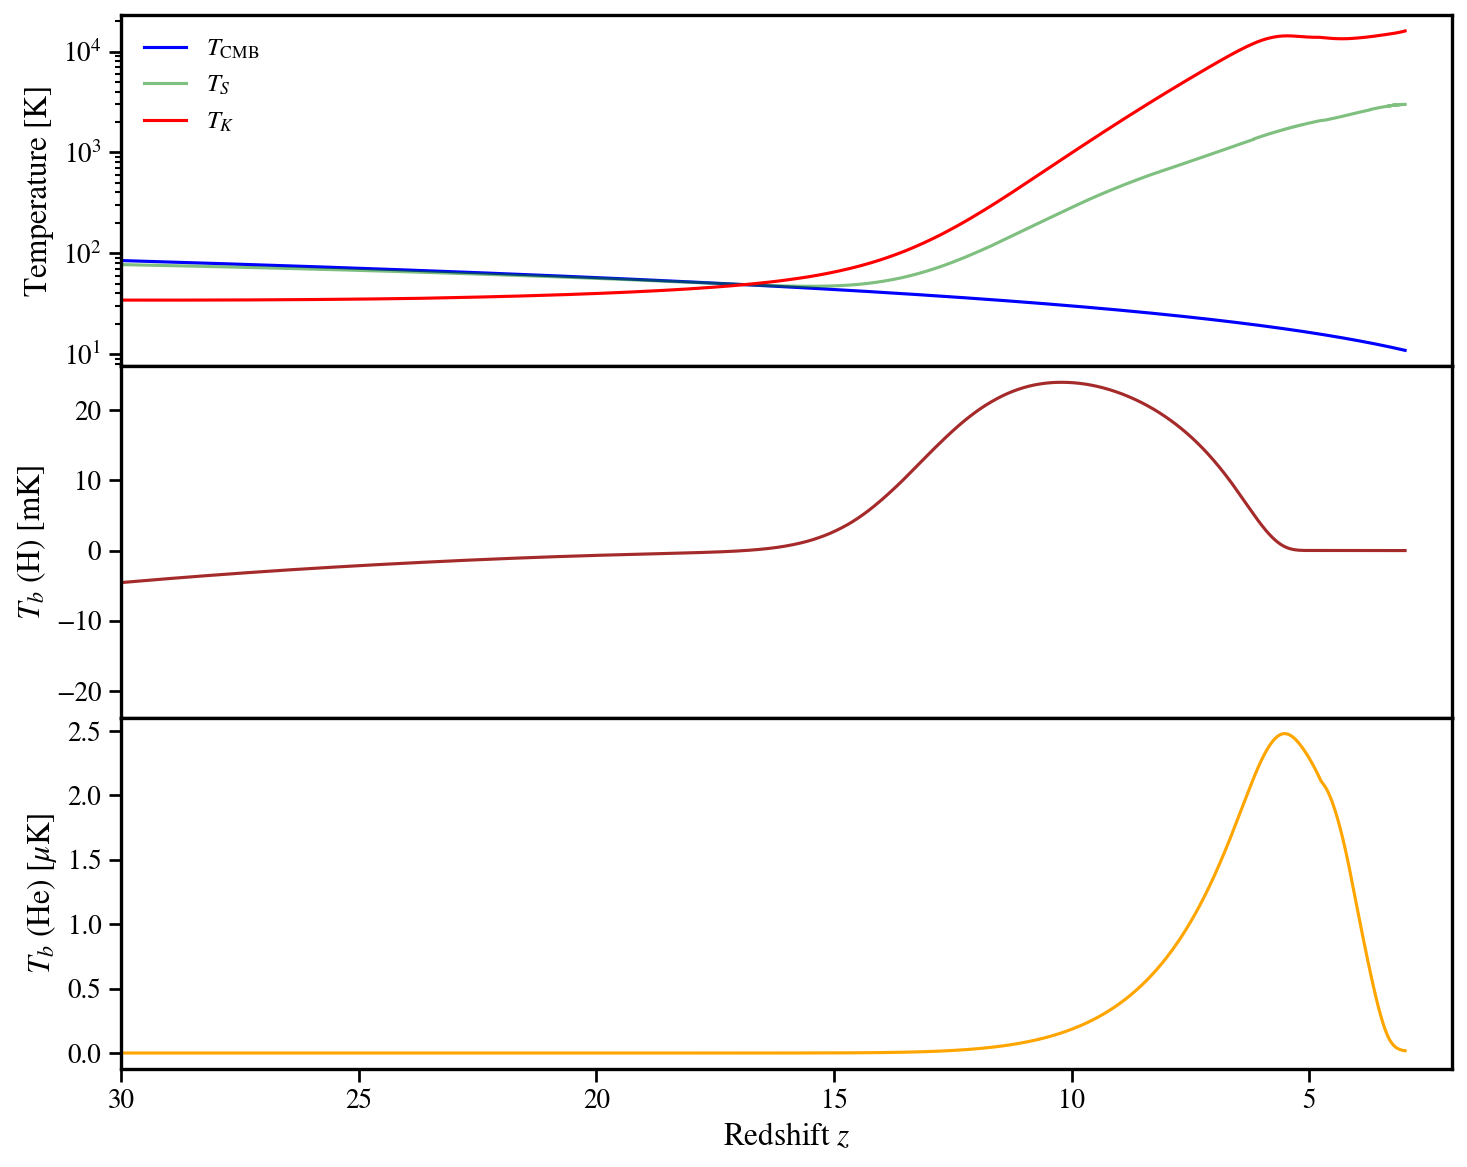

In [5]:
filename = f"./THESAN-XL_Z4_Pop2.csv"
df = pd.read_csv(filename)

df_1 =  pd.read_csv("./THESAN-1_Z4_Pop2.csv")
#df_pop3 =  pd.read_csv("./THESAN-XL_Z4_Pop3")
df_ext =  pd.read_csv("./THESAN-XL_Z4_EXT.csv")
df_pop3_3 =  pd.read_csv("./THESAN-Pop3_Z3.csv")
df_pop3_4 =  pd.read_csv("./THESAN-Pop3_Z4.csv")
df_pop3_5 =  pd.read_csv("./THESAN-Pop3_Z5.csv")
fig, axes = plt.subplots(
    3, 1,
    figsize=(10,8),
    sharex=True,
    gridspec_kw={"hspace":0}
)

z0 = df["redshift"].iloc[-1]
T0 = df["T_vol"].iloc[-1]   # your measured temperature

def T_ad(z):
    return T0 * ((1 + z) / (1 + z0))**2

# -------------------------
# (1) Temperatures
# -------------------------
ax = axes[0]
ax.plot(df["redshift"], T_CMB(df["redshift"]), color="blue", label=r'$T_\text{CMB}$')
ax.plot(df["redshift"], df["T_S"], color="green", alpha=0.5, label=r'$T_S $')
#ax.plot(df_1["redshift"], df_1["T_S"], color="green", alpha=0.5)#, label=r'$T_S $')
#ax.plot(df_pop3_3["redshift"], df_pop3_3["T_S"], color="green", alpha=0.5)#, label=r'$T_S $')
#ax.plot(df_pop3_4["redshift"], df_pop3_4["T_S"], color="green", alpha=0.5)#, label=r'$T_S $')
#ax.plot(df_pop3_5["redshift"], df_pop3_5["T_S"], color="green", alpha=0.5)#, label=r'$T_S $')
#ax.plot(df_ext["redshift"], df_ext["T_S"], color="green", alpha=0.5)#, label=r'$T_S $')
#ax.plot(df["redshift"], df["T_S_xe2"], color="green", alpha=0.5)#, label=r'$T_S \ (\times 10^2)$')
#ax.plot(df["redshift"], df["T_S_xe4"], color="green", alpha=0.5)#, label=r'$T_S \ (\times 10^4)$')
#ax.plot(df["redshift"], df["T_S_xe6"], color="green", alpha=0.5)#, label=r'$T_S \ (\times 10^6)$')
ax.plot(df["redshift"], df["T_vol"], color="red", label=r'$T_K$')
#ax.plot(df["redshift"], T_ad(df["redshift"]), color="cyan", label=r'$T_K(ad)$')
ax.set_ylabel("Temperature [K]", fontsize=15)
ax.set_yscale("log")
ax.legend(fontsize=12)

# -------------------------
# (3) 21-cm brightness temperature
# -------------------------
ax = axes[1]
ax.plot(df["redshift"], df["T_b"], color="brown")#, label=r"$T_b $")
#ax.plot(df_1["redshift"], df_1["T_b"], color="brown")
#ax.plot(df_pop3_3["redshift"], df_pop3_3["T_b"], color="brown")
#ax.plot(df_pop3_4["redshift"], df_pop3_4["T_b"], color="brown")
#ax.plot(df_pop3_5["redshift"], df_pop3_5["T_b"], color="brown")
#ax.plot(df_ext["redshift"], df_ext["T_b"], color="cyan")
#ax.plot(df["redshift"], df["T_b_F06"], label=r"$T_b (F06)$")
#ax.plot(df["redshift"], df["T_b_xe2"], color="brown")#, label=r"$T_b \ (\times 10^2)$")
#ax.plot(df["redshift"], df["T_b_xe4"], color="brown")#, label=r"$T_b \ (\times 10^4)$")
#ax.plot(df["redshift"], df["T_b_xe6"], color="brown")#, label=r"$T_b \ (\times 10^6)$")
#ax.plot(df["redshift"], df["T_b_F06_x100"], label=r"$T_b (x100) (F06)$")

ax.set_ylabel(r"$T_b$ (H) $[\mathrm{mK}]$", fontsize=15)
#ax.set_xlabel(r"Redshift $z$", fontsize=20)
#ax.legend(fontsize=12)


ax = axes[2]
ax.plot(df["redshift"], df["T_b_He"], color="orange", label=r"$T_b (HeII)$")
ax.set_ylabel(r"$T_b$ (He) $[\mu\mathrm{K}]$", fontsize=15)
ax.set_xlabel(r"Redshift $z$", fontsize=15)
#ax.legend(fontsize=12)


ax.set_xlim(2, 30)

# hide x tick labels on upper panels
axes[0].tick_params(labelbottom=False)
axes[1].tick_params(labelbottom=False)
#axes[2].tick_params(labelbottom=False)

ax.invert_xaxis()
plt.tight_layout()
plt.savefig("global.png", dpi=200)
plt.show()

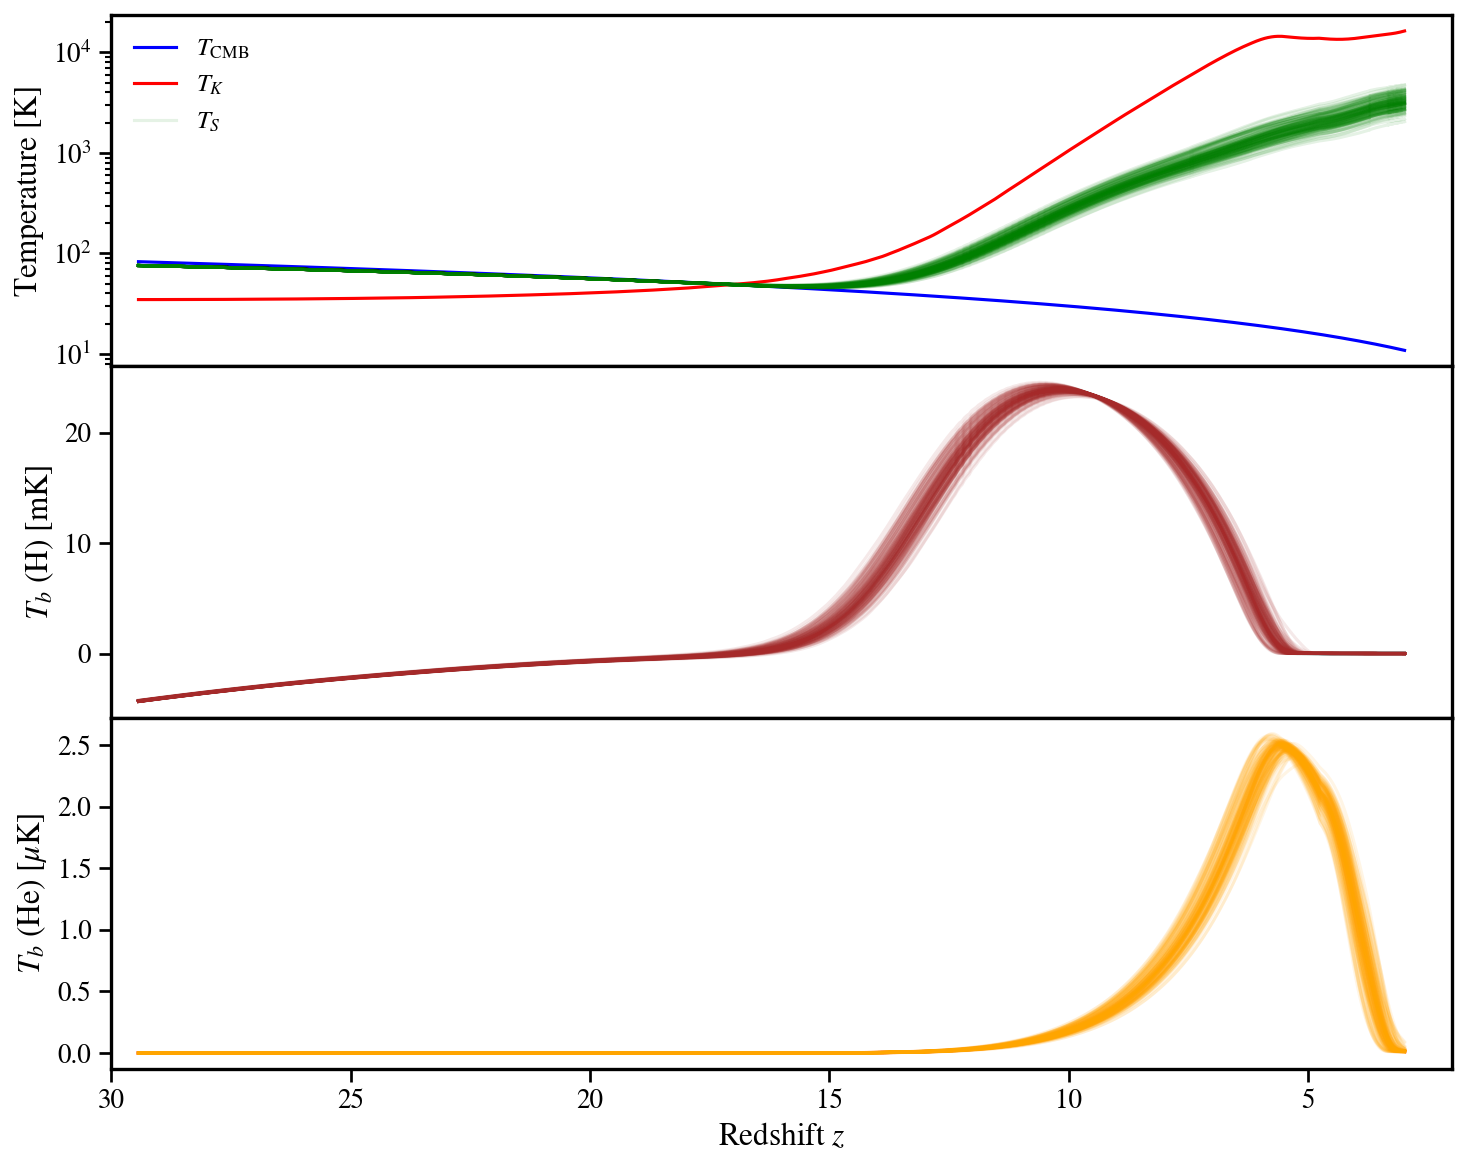

In [6]:
fig, axes = plt.subplots(
    3, 1,
    figsize=(10,8),
    sharex=True,
    gridspec_kw={"hspace":0}
)

for x in range(5):
    for y in range(5):
        for z in range(5):

            filename = f"./output_21cm/XL_ren5_{x}-{y}-{z}.csv"
            df = pd.read_csv(filename)
            # -------------------------
            # (1) Temperatures
            # -------------------------
            ax = axes[0]
            if x == 0 and y == 0 and z == 0:
                ax.plot(df["redshift"], T_CMB(df["redshift"]), color="blue", label=r'$T_\text{CMB}$')
                ax.plot(df["redshift"], df["T_vol"], color="red", label=r'$T_K$')
                ax.plot(df["redshift"], df["T_S"], color="green", alpha=0.1, label=r'$T_S $')
            ax.plot(df["redshift"], df["T_S"], color="green", alpha=0.1)
            #ax.plot(df["redshift"], df["T_S_xe2"], color="green", alpha=0.5)#, label=r'$T_S \ (\times 10^2)$')
            #ax.plot(df["redshift"], df["T_S_xe4"], color="green", alpha=0.5)#, label=r'$T_S \ (\times 10^4)$')
            #ax.plot(df["redshift"], df["T_S_xe6"], color="green", alpha=0.5)#, label=r'$T_S \ (\times 10^6)$')
            
            ax.set_ylabel("Temperature [K]", fontsize=15)
            ax.set_yscale("log")
            ax.legend(fontsize=12)
            
            # -------------------------
            # (3) 21-cm brightness temperature
            # -------------------------
            ax = axes[1]
            ax.plot(df["redshift"], df["T_b"], color="brown", alpha=0.1)#, label=r"$T_b $")
            #ax.plot(df["redshift"], df["T_b_F06"], label=r"$T_b (F06)$")
            #ax.plot(df["redshift"], df["T_b_xe2"], color="brown")#, label=r"$T_b \ (\times 10^2)$")
            #ax.plot(df["redshift"], df["T_b_xe4"], color="brown")#, label=r"$T_b \ (\times 10^4)$")
            #ax.plot(df["redshift"], df["T_b_xe6"], color="brown")#, label=r"$T_b \ (\times 10^6)$")
            #ax.plot(df["redshift"], df["T_b_F06_x100"], label=r"$T_b (x100) (F06)$")
            
            ax.set_ylabel(r"$T_b$ (H) $[\mathrm{mK}]$", fontsize=15)
            #ax.set_xlabel(r"Redshift $z$", fontsize=20)
            #ax.legend(fontsize=12)
            
            
            ax = axes[2]
            ax.plot(df["redshift"], df["T_b_He"], color="orange", alpha=0.1)# label=r"$T_b (HeII)$")
            ax.set_ylabel(r"$T_b$ (He) $[\mu\mathrm{K}]$", fontsize=15)
            ax.set_xlabel(r"Redshift $z$", fontsize=15)
            #ax.legend(fontsize=12)


ax.set_xlim(2, 30)

# hide x tick labels on upper panels
axes[0].tick_params(labelbottom=False)
axes[1].tick_params(labelbottom=False)
#axes[2].tick_params(labelbottom=False)

ax.invert_xaxis()
plt.tight_layout()
plt.savefig("local.png", dpi=200)
plt.show()

In [7]:
NU_LYMAN_ALPHA = 2.466e15 # n=2 (Ly_alpha)
NU_LYMAN_BETA  = 2.925e15 # n=3 (Ly_beta)
NU_LYMAN_GAMMA = 3.083e15 # n=4 (Ly_gamma)
NU_LYMAN_DELTA = 3.158e15 # n=5 (Ly_delta)
NU_LYMAN_LIMIT = 3.289e15 # Hz (n=infinity, ionization potential)

# Planck's constant (erg s)
PLANCK = 6.62607015e-27
# Wavelength of 21 cm
LAMBDA_21cm = 21.106 
# Wavelength of Lyman-alpha (1215.67 Angstroms, converted to cm)
LAMBDA_1216 = 1215.67e-8

# Boltzmann constant (ergs per kelvin)
k_B = 1.381e-16 
# Hubble constant (Little h)
h = 0.6774
# Hubble constant at the present day
H_0 = 100 * h
H_0_cgs = 100.0 * h * 3.241e-20 # convert from km/s/Mpc to cm^{-1}
# Spontaneous decay rate of the spin flip transition A_10 (per s) 
A_10 = 2.85e-15 

M_SOL = 1.988e33 # 1 Solar mass in grams
YR = 31556736
G_cgs = 6.6743015e-8 # Gravitational Constant #dyn cm^2 g^{−2}
m_p = 1.6738e-24 # Neutral hydrogen mass
e_cgs = 4.803204712570263e-10   # statC (esu)
me_cgs = const.m_e.cgs.value    # g
C_LIGHT  = const.c.cgs.value      # cm / s
X_H = 0.76 # hydrogen fraction
msol_cgs = 1.988e33
yr_sec = 3.154e7 

OMEGA_b = 0.0486 # THESAN (Kannan et al. 2022) / 0.044 (Furlanetto et al. 2006)
OMEGA_m = 0.3089 # THESAN (Kannan et al. 2022)  / 0.26 (Furlanetto et al. 2006)
OMEGA_Lambda = 0.6911 #THESAN (Kannan et al. 2022) / 0.74 (Furlanetto et al. 2006)

# T_star (kelvin)
T_star = PLANCK * C_LIGHT / (k_B * LAMBDA_21cm)

In [8]:
df_1_10 = pd.read_csv("THESAN-1_10.csv")
df_1_100 = pd.read_csv("THESAN-1_100.csv")
df_xl_10 = pd.read_csv("THESAN-XL_10.csv")
df_xl_10_x = pd.read_csv("THESAN-XL_10_Xray.csv")
df_xl_100 = pd.read_csv("THESAN-XL_100.csv")
df_xl_10_b = pd.read_csv("THESAN-XL_10_X-ray(boosted).csv")
df_xl_100_b = pd.read_csv("THESAN-XL_100_X-ray(boosted).csv")
df_xl_10_z3 = pd.read_csv("THESAN-XL_10_Z3.csv")
df_xl_10_z3_ts = pd.read_csv("THESAN-XL_10_Z3_TS.csv")
df_xl_10_z2_ts = pd.read_csv("THESAN-XL_10_Z2_TS.csv")
#"THESAN-XL_10_Z2_TS.csv"

df_xl_250_z2 = pd.read_csv("THESAN-XL_250_Z2.csv")
df_xl_250_z3 = pd.read_csv("THESAN-XL_250_Z3.csv")
df_xl_250_z4 = pd.read_csv("THESAN-XL_250_Z4.csv")
df_xl_100_z2 = pd.read_csv("THESAN-XL_100_Z2.csv")
df_xl_100_z3 = pd.read_csv("THESAN-XL_100_Z3.csv")
df_xl_100_z4 = pd.read_csv("THESAN-XL_100_Z4.csv")
df_xl_10_z2 = pd.read_csv("THESAN-XL_10_Z2.csv")
df_xl_10_z3 = pd.read_csv("THESAN-XL_10_Z3.csv")
df_xl_z4_cell = pd.read_csv("THESAN-XL_10_Z4_pixel-00-00-00.csv")
df_xl_z4 = pd.read_csv("THESAN-XL_Z4.csv")
df_1_z4 = pd.read_csv("THESAN-1_Z4.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'THESAN-1_10.csv'

In [ ]:
df = pd.read_csv("XL_ren5_0-0-0.csv")
df_another = df = pd.read_csv("XL_ren5_4-4-0.csv")

In [ ]:
plt.plot(df["redshift"], df["SFR"], alpha=0.7, label="0,4,0")
plt.plot(df_another["redshift"], df_another["SFR"], alpha=0.7, label="1,3,0")
plt.legend()
plt.yscale("log")
plt.xlim(30,2)

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

# -------------------------
# (1) Temperatures
# -------------------------
ax = axes[0]
ax.plot(df["redshift"], df["T_CMB"], label=r'$T_\text{CMB}$')
ax.plot(df["redshift"], df["T_S"], label=r'$T_S$')
ax.plot(df["redshift"], df["T_vol"], label=r'$T_K$')

ax.plot(df_another["redshift"], df_another["T_CMB"], label=r'1$T_\text{CMB}$')
ax.plot(df_another["redshift"], df_another["T_S"], label=r'1$T_S$')
ax.plot(df_another["redshift"], df_another["T_vol"], label=r'1$T_K$')

ax.set_ylabel("Temperature [K]", fontsize=20)
ax.set_yscale("log")
ax.legend(fontsize=15)

# -------------------------
# (2) Star formation rate density
# -------------------------
ax = axes[1]
#ax.scatter(df["redshift"], SFRD(df["redshift"]), alpha=0.7, label="SFRD_fun")
ax.scatter(df["redshift"], df["SFRD"], alpha=0.7, label="SFRD")
ax.scatter(df_another["redshift"], df_another["SFRD"], alpha=0.7, label="1SFRD")
ax.set_ylabel(r"$\dot{\rho}_\star\;[\mathrm{g\,s^{-1}\,cm^{-3}}]$", fontsize=20)
ax.set_yscale("log")
ax.legend(fontsize=15)

# -------------------------
# (3) 21-cm brightness temperature
# -------------------------
ax = axes[2]
ax.plot(df["redshift"], df["T_b"], label=r"$T_b (PL12)$")
ax.plot(df_another["redshift"], df_another["T_b"], label=r"1$T_b (PL12)$")
ax.set_ylabel(r"$T_b (H_I)\;[\mathrm{mK}]$", fontsize=20)
ax.set_xlabel(r"Redshift $z$", fontsize=20)
ax.legend(fontsize=15)

# -------------------------
# (3) 21-cm brightness temperature
# -------------------------
ax = axes[3]
ax.plot(df["redshift"], df["T_b_He"], label=r"$T_b (HeII)$")
ax.plot(df_another["redshift"], df_another["T_b_He"], label=r"1$T_b (HeII)$")
ax.set_ylabel(r"$T_b (He_{II}) \;[\mu\mathrm{K}]$", fontsize=20)
ax.set_xlabel(r"Redshift $z$", fontsize=20)
ax.legend(fontsize=15)

ax.set_xlim(1, 30)
#ax.set_xlim(3, 10)

ax.invert_xaxis()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# Create the targets: 10, 9.5, 9.0 ... 3.0
target_redshifts = np.arange(20, 2.5, -0.5) 

print(target_redshifts)
# Output: [10.  9.5  9.   8.5  8.   7.5  7.   6.5  6.   5.5  5.   4.5  4.   3.5  3. ]
closest_snapshots = []

for target_z in target_redshifts:
    # Find the index where the absolute difference is minimal
    idx = (df_xl_z4_cell["redshift"] - target_z).abs().idxmin()
    
    # Get the actual redshift value at that index
    actual_z = df_xl_z4_cell.loc[idx, "redshift"]
    
    # Store the info (target, index, and actual value)
    closest_snapshots.append({
        'target': target_z,
        'index': idx,
        'actual_redshift': actual_z
    })

# Convert to DataFrame for a nice view
df_results = pd.DataFrame(closest_snapshots)
print(df_results)

In [ ]:
# Find the index of the minimum absolute difference
closest_idx = (df_xl_z4_cell["redshift"] - target_z).abs().idxmin()

print(f"Closest snapshot for z = {target_z}: {closest_idx}")
#print(df_xl_z4_cell.loc[closest_idx])

In [ ]:
df_1 =  pd.read_csv("./output_21cm/THESAN-XL_Z4.csv")


In [9]:
# CMB brightness temperature at z: T_CMB(z)
def T_CMB(z):
    T_CMB_0 = 2.7255 # Kelvin
    return T_CMB_0 * (1.0 + z)


In [10]:
def T_ad(df):
    T_adiabatic = df["T_vol"][0] * ((1.0 + df["redshift"])/(1.0 + df["redshift"][0]))**2.0
    return T_adiabatic

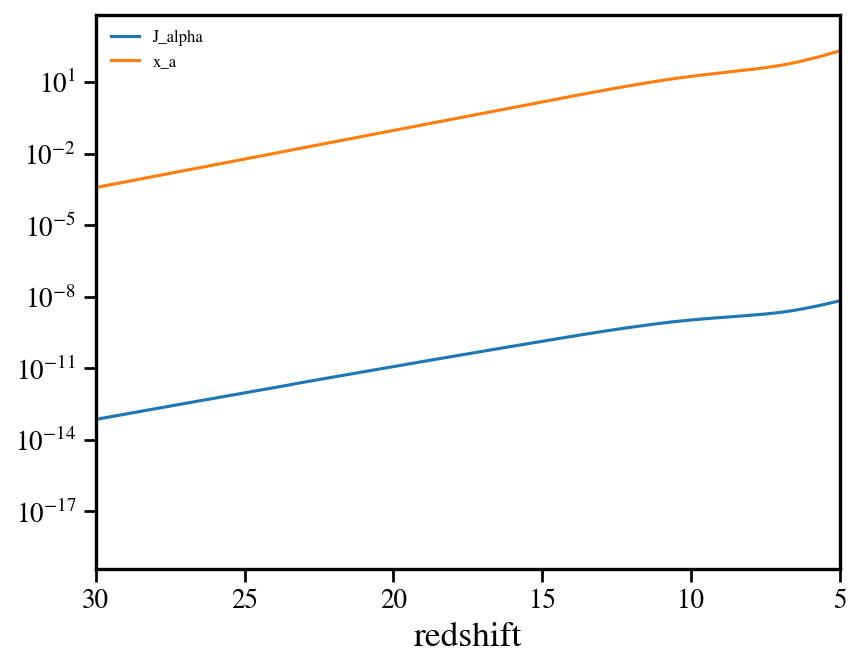

In [11]:

plt.plot(df_1["redshift"], df_1["J_alpha"], label="J_alpha")
plt.plot(df_1["redshift"], df_1["x_a"], label="x_a")
#plt.plot(df["redshift"], df["x_a_X"], label="x_a_X")
#plt.plot(z,x_alpha, label="x_a (popIII)")
#plt.plot(df["redshift"], df["num_HI"], label="num_HI")
#plt.plot(df["redshift"], df["num_e"], label="num_e")
#plt.plot(df["redshift"], df["num_p"], label="num_p")
plt.xlabel("redshift")
plt.yscale("log")
plt.legend()
plt.xlim(30, 5)
#plt.ylim(5, 300)
plt.show()

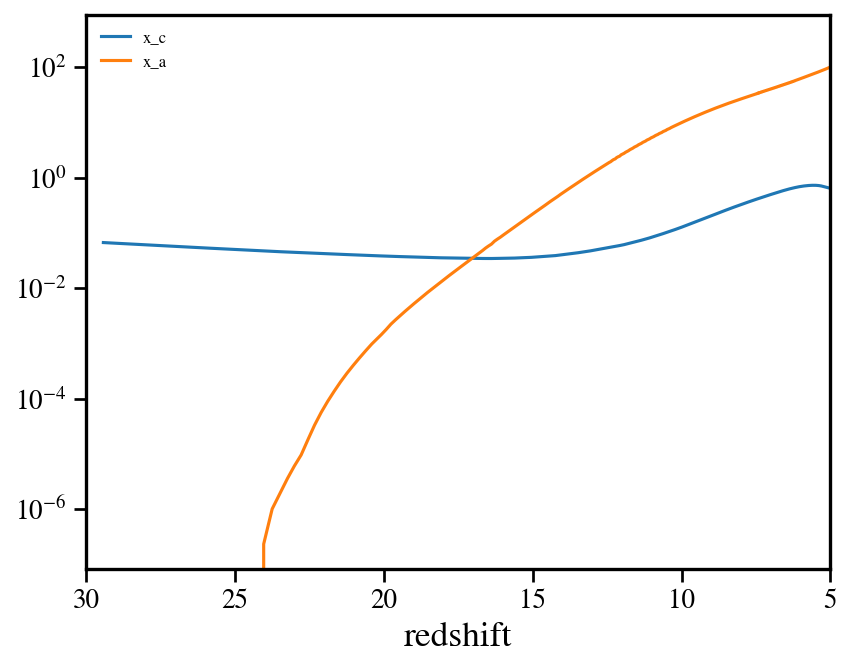

In [12]:
plt.plot(df["redshift"], df["x_c"], label="x_c")
plt.plot(df["redshift"], df["x_a"], label="x_a")
#plt.plot(df["redshift"], df["x_a_X"], label="x_a_X")
#plt.plot(z,x_alpha, label="x_a (popIII)")
#plt.plot(df["redshift"], df["num_HI"], label="num_HI")
#plt.plot(df["redshift"], df["num_e"], label="num_e")
#plt.plot(df["redshift"], df["num_p"], label="num_p")
plt.xlabel("redshift")
plt.yscale("log")
plt.legend()
plt.xlim(30, 5)
#plt.ylim(5, 300)
plt.show()

In [13]:
df

,redshift,a,M_gas,density,SpectralDensity,HII_fraction,HeII_fraction,HeIII_fraction,sfr,sfrd,...,J_alpha_xe6,x_a_xe2,x_a_xe4,x_a_xe6,T_S_xe2,T_S_xe4,T_S_xe6,T_b_xe2,T_b_xe4,T_b_xe6
0,2.990499,0.250595,1.177681e+49,4.008445e-31,3.896600e-31,9.999870e-01,7.460670e-04,7.820091e-02,94171.550,3.205294e-75,...,0.006934,31350.870184,3.135087e+06,3.135087e+08,13948.892486,14537.179202,14543.313016,0.000221,0.000221,0.000221
1,2.994312,0.250356,1.177778e+49,4.008774e-31,3.896997e-31,9.999870e-01,7.584700e-04,7.818850e-02,94000.690,3.199479e-75,...,0.006914,31232.318937,3.123232e+06,3.123232e+08,13939.840462,14529.084555,14535.228925,0.000222,0.000222,0.000222
2,2.998129,0.250117,1.177839e+49,4.008982e-31,3.897275e-31,9.999869e-01,7.711090e-04,7.817586e-02,94158.914,3.204864e-75,...,0.006918,31218.143054,3.121814e+06,3.121814e+08,13932.779554,14521.106204,14527.240743,0.000223,0.000223,0.000223
3,3.001949,0.249878,1.177970e+49,4.009429e-31,3.897786e-31,9.999868e-01,7.839640e-04,7.816300e-02,94156.230,3.204773e-75,...,0.006901,31111.913710,3.111191e+06,3.111191e+08,13924.108657,14513.191504,14519.334408,0.000224,0.000224,0.000224
4,3.005773,0.249640,1.178066e+49,4.009755e-31,3.898180e-31,9.999868e-01,7.970214e-04,7.814994e-02,93739.266,3.190581e-75,...,0.006903,31092.792962,3.109279e+06,3.109279e+08,13917.188254,14505.463900,14511.598167,0.000225,0.000225,0.000225
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
703,27.624245,0.034935,1.236703e+49,4.209335e-31,4.193827e-31,9.995297e-07,7.920907e-08,7.864482e-08,0.000,0.000000e+00,...,0.000000,0.000000,0.000000e+00,0.000000e+00,72.646005,72.646005,72.646005,-3.367695,-3.367695,-3.367695
704,28.065021,0.034406,1.236798e+49,4.209658e-31,4.194407e-31,9.995448e-07,7.920173e-08,7.865326e-08,0.000,0.000000e+00,...,0.000000,0.000000,0.000000e+00,0.000000e+00,73.472596,73.472596,73.472596,-3.589526,-3.589526,-3.589526
705,28.512585,0.033884,1.236891e+49,4.209976e-31,4.194978e-31,9.995595e-07,7.919429e-08,7.866181e-08,0.000,0.000000e+00,...,0.000000,0.000000,0.000000e+00,0.000000e+00,74.296238,74.296238,74.296238,-3.823674,-3.823674,-3.823674
706,28.967040,0.033370,1.236983e+49,4.210289e-31,4.195539e-31,9.995707e-07,7.918675e-08,7.867048e-08,0.000,0.000000e+00,...,0.000000,0.000000,0.000000e+00,0.000000e+00,75.116136,75.116136,75.116136,-4.070822,-4.070822,-4.070822


In [14]:
df_1 =  pd.read_csv("./output_21cm/THESAN-XL_Z4.csv")

df = df_1

(1e-17, 1e-07)

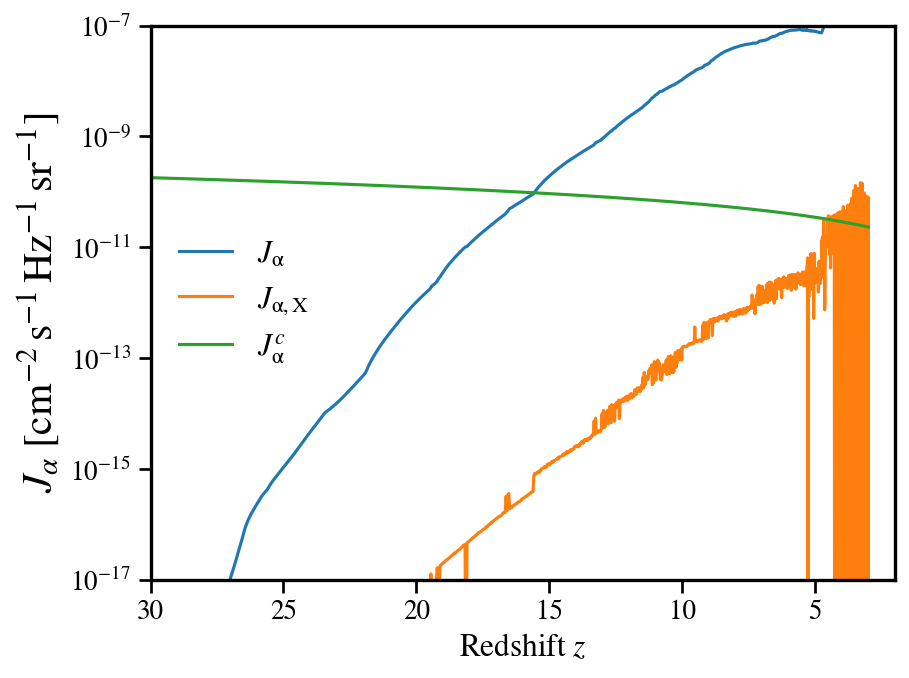

In [15]:
def J_crit(z):
    return 1.165e-10*(1.0+z)/20 # critical J_alpha flux

plt.plot(df["redshift"], df["J_alpha"], label=r"$J_\mathrm{\alpha}$")
#plt.plot(df["redshift"], df["J_alpha_xe2"], label=r"$J_\mathrm{\alpha} \ (\times 10^2)$")
#plt.plot(df["redshift"], df["J_alpha_xe4"], label=r"$J_\mathrm{\alpha} \ (\times 10^4)$")
#plt.plot(df["redshift"], df["J_alpha_xe6"], label=r"$J_\mathrm{\alpha} \ (\times 10^6)$")
plt.plot(df["redshift"], df["J_alpha_X"], label=r"$J_\mathrm{\alpha, X}$")
plt.plot(df["redshift"], J_crit(df["redshift"]), label=r"$J^{c}_\mathrm{\alpha}$")


plt.xlabel(r"Redshift $z$", fontsize=15)
plt.ylabel(r"$J_\alpha\;[\mathrm{cm^{-2}\,s^{-1}\,Hz^{-1}\,sr^{-1}}]$", fontsize=20)
plt.yscale("log")
plt.legend(fontsize=15)
plt.xlim(30,2)
plt.ylim(1.0e-17,1.0e-7)

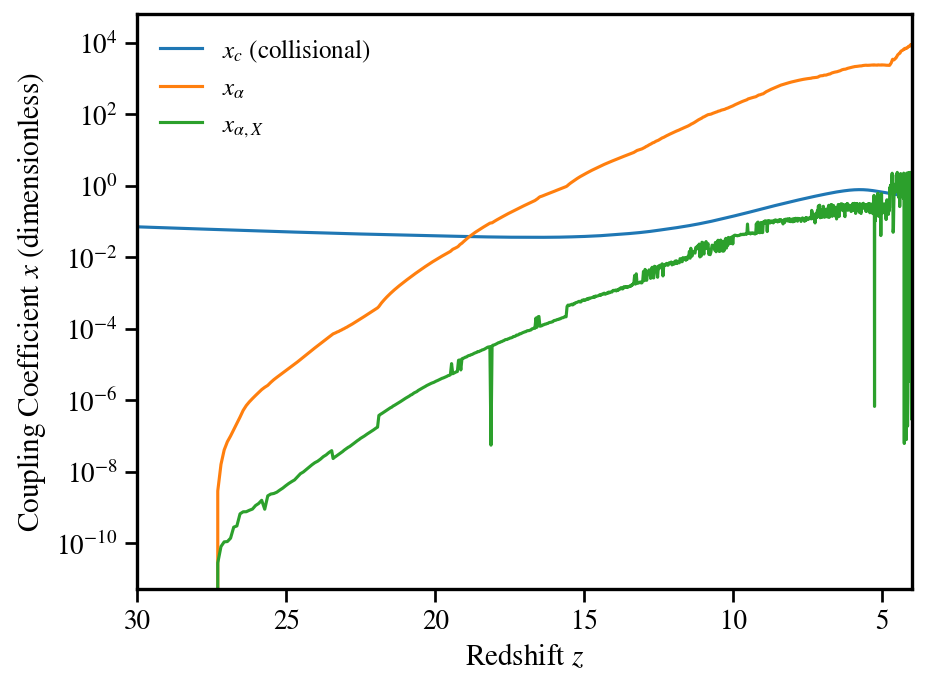

In [16]:
z = np.array([35, 30, 25, 20, 15])
x_alpha = np.array([0.0003, 0.006, 0.08, 0.79, 5.3])

plt.plot(df["redshift"], df["x_c"], label=r"$x_c$ (collisional)")
plt.plot(df["redshift"], df["x_a"], label=r"$x_\alpha$")
plt.plot(df["redshift"], df["x_a_X"], label=r"$x_{\alpha,X}$")

plt.xlabel(r"Redshift $z$", fontsize=14)
plt.ylabel(r"Coupling Coefficient $x$ (dimensionless)", fontsize=14)

plt.yscale("log")
plt.xlim(30, 4)

plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

NameError: name 'df_xl_z4' is not defined

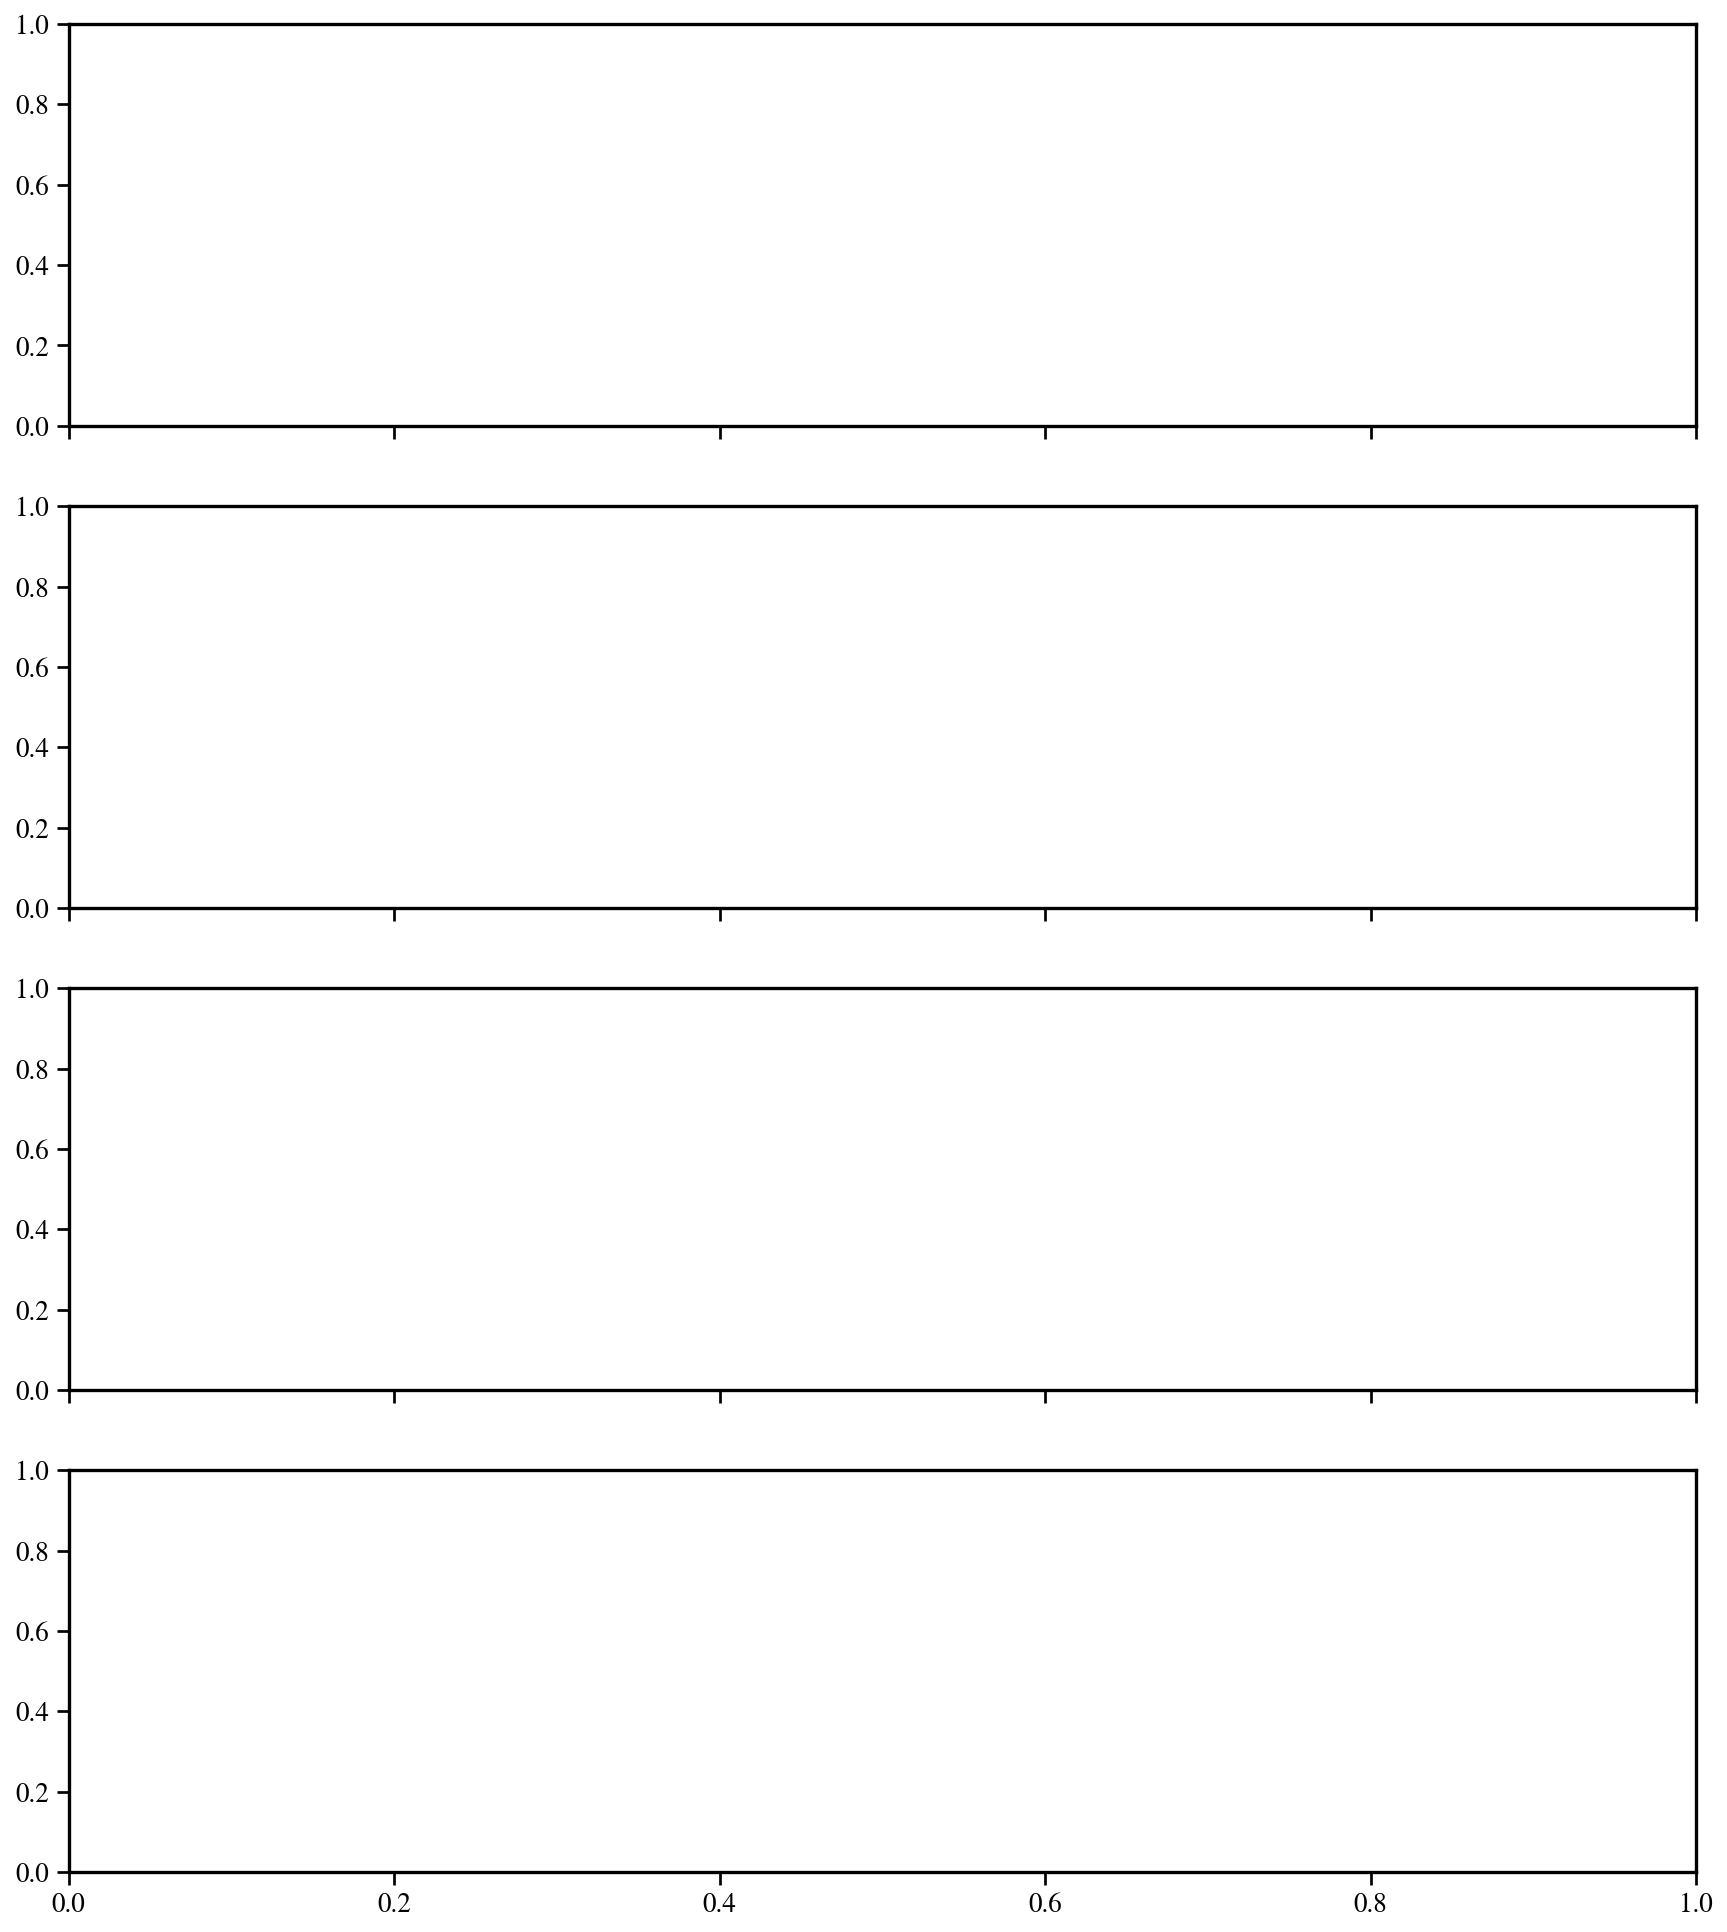

In [17]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)

# -------------------------
# (1) Temperatures
# -------------------------
ax = axes[0]
ax.plot(df_xl_z4["redshift"], df_xl_z4["T_CMB"], label=r'$T_\text{CMB}$')
ax.plot(df_xl_z4["redshift"], df_xl_z4["T_S"], label=r'$T_S$')
ax.plot(df_xl_z4["redshift"], df_xl_z4["T_vol"], label=r'$T_K$')
ax.set_ylabel("Temperature [K]", fontsize=20)
ax.set_yscale("log")
ax.legend(fontsize=15)

# -------------------------
# (2) Star formation rate density
# -------------------------
ax = axes[1]
#ax.scatter(df["redshift"], SFRD(df["redshift"]), alpha=0.7, label="SFRD_fun")
#ax.scatter(df_xl_z4["redshift"], df_xl_z4["SFRD"], alpha=0.7, label="SFRD")
ax.set_ylabel(r"$\dot{\rho}_\star\;[\mathrm{g\,s^{-1}\,cm^{-3}}]$", fontsize=20)
ax.set_yscale("log")
ax.legend(fontsize=15)

# -------------------------
# (3) 21-cm brightness temperature
# -------------------------
ax = axes[2]
ax.plot(df_xl_z4["redshift"], df_xl_z4["T_b_PL12"], label=r"$T_b (PL12)$")
ax.plot(df_xl_z4["redshift"], df_xl_z4["T_b_F06"], label=r"$T_b (F06)$")
ax.set_ylabel(r"$T_b (H_I)\;[\mathrm{mK}]$", fontsize=20)
ax.set_xlabel(r"Redshift $z$", fontsize=20)
ax.legend(fontsize=15)

# -------------------------
# (3) 21-cm brightness temperature
# -------------------------
ax = axes[3]
ax.plot(df_xl_z4["redshift"], df_xl_z4["T_b_He"], label=r"$T_b (HeII)$")
ax.set_ylabel(r"$T_b (He_{II}) \;[\mu\mathrm{K}]$", fontsize=20)
ax.set_xlabel(r"Redshift $z$", fontsize=20)
ax.legend(fontsize=15)

ax.set_xlim(1, 30)
#ax.set_xlim(3, 10)

ax.invert_xaxis()
plt.tight_layout()
plt.show()

In [ ]:
z = np.array([35, 30, 25, 20, 15])
x_alpha = np.array([0.0003, 0.006, 0.08, 0.79, 5.3])

#plt.plot(df["redshift"], df["T_CMB"], label="T_CMB")
#plt.plot(df["redshift"], T_ad(df), label="T_K (Adiabatic)")
#plt.plot(df["redshift"], df["T_b_F06"], label="T_b")
#plt.plot(df["redshift"], df["T_vol"], label="T_K")
#plt.plot(df["redshift"], df["T_S"], label="T_S")
plt.plot(df["redshift"], df["S_alpha"], label="S_alpha")
#plt.plot(df["redshift"], df["x_c"], label="x_c")
#plt.plot(df["redshift"], df["x_a"], label="x_a")
#plt.plot(z,x_alpha, label="x_a (popIII)")
#plt.plot(df["redshift"], df["num_HI"], label="num_HI")
#plt.plot(df["redshift"], df["num_e"], label="num_e")
#plt.plot(df["redshift"], df["num_p"], label="num_p")
plt.xlabel("redshift")
#plt.yscale("log")
plt.legend()
plt.xlim(10, 50)
#plt.ylim(5, 300)
plt.show()

In [18]:
plt.figure(figsize=(14,5))
#plt.plot(df_1_10["redshift"], T_CMB(df_1_10["redshift"]), label='CMB temperature')
plt.plot(df_xl_10["redshift"], T_CMB(df_xl_10["redshift"]), label=r'$T_\text{CMB}$')

#plt.plot(df_1_10["redshift"], df_1_10["T_vol"], label=r'$T_K$ (THESAN-1)')
plt.plot(df_xl_10["redshift"], df_xl_10["T_vol"], label=r'$T_K$')
plt.plot(df["redshift"], df["T_S"], label="T_S")


#plt.plot(df_1_10["redshift"], df_1_10["T_S"], label=r'$T_S$ (THESAN-1)')
#plt.plot(df_1_100["redshift"], df_1_100["T_S"], label=r'$T_S$ (THESAN-1_100)')

#plt.plot(df_xl_10["redshift"], df_xl_10["T_S"], label=r'$T_S$ (10 Myr $10^{-4} Z_\odot$)')
#plt.plot(df_xl_100["redshift"], df_xl_100["T_S"], label=r'$T_S$ (100 Myr $10^{-4} Z_\odot$)')

#plt.plot(df_xl_10_z3["redshift"], df_xl_10_z3["T_S"], label=r'$T_S$ (10 Myr $10^{-3} Z_\odot$)')

#plt.plot(df_xl_10_z4["redshift"], df_xl_10_z4["T_S"], label=r'$T_S$ (10 Myr $10^{-4} Z_\odot$)')
#plt.plot(df_xl_10_z3["redshift"], df_xl_10_z3["T_S"], label=r'$T_S$ (10 Myr $10^{-3} Z_\odot$)')
#plt.plot(df_xl_10_z2["redshift"], df_xl_10_z2["T_S"], label=r'$T_S$ (10 Myr $10^{-2} Z_\odot$)')

#plt.plot(df_xl_100_z4["redshift"], df_xl_100_z4["T_S"], label=r'$T_S$ (100 Myr $10^{-4} Z_\odot$)')
#plt.plot(df_xl_100_z3["redshift"], df_xl_100_z3["T_S"], label=r'$T_S$ (100 Myr $10^{-3} Z_\odot$)')
#plt.plot(df_xl_100_z2["redshift"], df_xl_100_z2["T_S"], label=r'$T_S$ (100 Myr $10^{-2} Z_\odot$)')

#plt.plot(df_xl_250_z4["redshift"], df_xl_250_z4["T_S"], label=r'$T_S$ (250 Myr $10^{-4} Z_\odot$)')
#plt.plot(df_xl_250_z3["redshift"], df_xl_250_z3["T_S"], label=r'$T_S$ (250 Myr $10^{-3} Z_\odot$)')
#plt.plot(df_xl_250_z2["redshift"], df_xl_250_z2["T_S"], label=r'$T_S$ (250 Myr $10^{-2} Z_\odot$)')


#plt.plot(df_xl_10_b["redshift"], df_xl_10_b["T_S"], label=r'$T_S$ (Boosted THESAN-XL_10)')
#plt.plot(df_xl_10_x["redshift"], df_xl_10_x["T_S"], label=r'$T_S$ (THESAN-XL_10_X-ray)')
#plt.plot(df_xl_100_b["redshift"], df_xl_100_b["T_S"], label=r'$T_S$ (Boosted THESAN-XL_100)')

#plt.plot(df["redshift"][::steps], T_b_array)
#plt.plot(df["redshift"][::steps], T_b_other_array)
#::steps]
plt.ylim(15,40000)
plt.xlabel(r"redshift $z$", fontsize=15)
plt.ylabel("temperature [K]", fontsize=15)
plt.legend()
plt.yscale("log")
# Reverse X-axis
plt.gca().invert_xaxis()

plt.tight_layout()
plt.show()

NameError: name 'df_xl_10' is not defined

<Figure size 2100x750 with 0 Axes>

In [19]:
plt.figure(figsize=(14,5))
#plt.plot(df_1_10["redshift"], df_1_10["T_b"], label=r'$T_b$ (THESAN-1_10)')
#plt.plot(df_1_100["redshift"], df_1_100["T_b"], label=r'$T_b$ (THESAN-1_100)')
#plt.plot(df_xl_10["redshift"], df_xl_10["T_b"], label=r'$T_b$ (10 Myr $10^{-4} Z_\odot$)')
#plt.plot(df_xl_10_x["redshift"], df_xl_10_x["T_b"], label=r'$T_b$ (THESAN-XL_10_X-ray)')
#plt.plot(df_xl_100["redshift"], df_xl_100["T_b"], label=r'$T_b$ (100 Myr $10^{-4} Z_\odot$)')


plt.plot(df["redshift"], df["T_b_F06"], label=r'$T_b$')

#plt.plot(df_xl_10_z4["redshift"], df_xl_10_z4["T_b"], label=r'$T_b$ (10 Myr $10^{-4} Z_\odot$)')
plt.plot(df_xl_10_z3["redshift"], df_xl_10_z3["T_b"], label=r'$T_b$ (10 Myr $10^{-3} Z_\odot$)')
#plt.plot(df_xl_10_z2["redshift"], df_xl_10_z2["T_b"], label=r'$T_b$ (10 Myr $10^{-2} Z_\odot$)')

#plt.plot(df_xl_100_z4["redshift"], df_xl_100_z4["T_b"], label=r'$T_b$ (100 Myr $10^{-4} Z_\odot$)')
plt.plot(df_xl_100_z3["redshift"], df_xl_100_z3["T_b"], label=r'$T_b$ (100 Myr $10^{-3} Z_\odot$)')
#plt.plot(df_xl_100_z2["redshift"], df_xl_100_z2["T_b"], label=r'$T_b$ (100 Myr $10^{-2} Z_\odot$)')

#plt.plot(df_xl_250_z4["redshift"], df_xl_250_z4["T_b"], label=r'$T_b$ (250 Myr $10^{-4} Z_\odot$)')
plt.plot(df_xl_250_z3["redshift"], df_xl_250_z3["T_b"], label=r'$T_b$ (250 Myr $10^{-3} Z_\odot$)')
#plt.plot(df_xl_250_z2["redshift"], df_xl_250_z2["T_b"], label=r'$T_b$ (250 Myr $10^{-2} Z_\odot$)')


#plt.plot(df_xl_10_b["redshift"], df_xl_10_b["T_b"], label=r'$T_b$ (Boosted THESAN-XL_10)')
#plt.plot(df_xl_100_b["redshift"], df_xl_100_b["T_b"], label=r'$T_b$ (Boosted THESAN-XL_100)')

#plt.plot(df["redshift"][::steps], T_b_other_array)

plt.xlabel(r"redshift ($z$)", fontsize=15)
plt.ylabel(r"$T_b$ [mK]", fontsize=15)
plt.legend()
plt.ylim(-60,30)
#plt.yscale("log")
# Reverse X-axis
plt.gca().invert_xaxis()

plt.tight_layout()
plt.show()

KeyError: 'T_b_F06'

<Figure size 2100x750 with 0 Axes>

In [ ]:
plt.plot(df_xl_10_z4["redshift"], df_xl_10_z4["num_HeI"]/(df_xl_10_z4["num_HeI"]+df_xl_10_z4["num_HeII"]+df_xl_10_z4["num_HeIII"]), label="HeI")
plt.plot(df_xl_10_z4["redshift"], df_xl_10_z4["num_HeII"]/(df_xl_10_z4["num_HeI"]+df_xl_10_z4["num_HeII"]+df_xl_10_z4["num_HeIII"]), label="HeII")
plt.plot(df_xl_10_z4["redshift"], df_xl_10_z4["num_HeIII"]/(df_xl_10_z4["num_HeI"]+df_xl_10_z4["num_HeII"]+df_xl_10_z4["num_HeIII"]), label="HeIII")
plt.xlabel(r"Redshift $z$")
plt.ylabel(r"Fraction $f_\lambda$")
plt.legend()
plt.xlim(4, 12)

In [ ]:
df.to_csv("THESAN-XL_Z4.csv", index=False)


In [ ]:
def get_sfr(file_path):
    # Define the column names
    cols = [
        "a",
        "dummy1",
        "dummy2",
        "sfr",
        "dummy4",
        "m_s_cum"
    ]
    
    # Read the whitespace-separated table
    df = pd.read_csv(file_path, 
                     delim_whitespace=True, 
                     names=cols,
                     comment="#",     # in case there are comment lines
                     header=None)
    return df

thesan_path = "/nfs/mvogelsblab001/Thesan/Thesan-1/output"
xl_path = "/orcd/data/mvogelsb/005/mkilab001/mvogelsblab003/Lab/Thesan-XL/Flagship/output"

output_path = thesan_path #xl_path

box_length = 64691.7*3.08568e+21 # box size to cm: THESAN (64.7 Mpc)
#7.797568573148436e+23 # box size to cm: THESAN (252.7 kpc)
#338300*3.08568e+21 # THESAN-XL (338.3 Mpc)

box_volume = box_length * box_length * box_length
sfr_path = f"{output_path}/sfr.txt"
df_sfr_1 = get_sfr(sfr_path)
df_sfr_1["redshift"] = (1.0/df_sfr_1["a"]) - 1.0
df_sfr_1["SFRD"] = df_sfr_1["sfr"] * msol_cgs / (yr_sec * box_volume) # g sec^{-1} cm^{-3}
df_sfr_1

/tmp/ipykernel_962212/2846074076.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path,


,a,dummy1,dummy2,sfr,dummy4,m_s_cum,redshift,SFRD
0,0.058457,0.000000e+00,235.11010,0.000000,0.000000,0.000000,16.106658,0.000000e+00
1,0.058487,1.125409e-06,22.94792,0.088447,0.000000,0.000000,16.097910,7.008760e-55
2,0.058502,6.239669e-08,23.03396,0.009803,0.000000,0.000000,16.093538,7.767843e-56
3,0.058517,8.149883e-05,22.97571,12.798750,0.000112,0.000112,16.089165,1.014201e-52
4,0.058532,3.591343e-07,26.15284,0.056378,0.000000,0.000112,16.084794,4.467481e-55
...,...,...,...,...,...,...,...,...
298224,0.155153,1.061390e-07,25146.99000,0.992115,0.000000,38.426580,5.445234,7.861736e-54
298225,0.155153,6.574553e-03,25139.21000,61454.370000,0.006606,38.433180,5.445230,4.869777e-49
298226,0.155154,1.098192e-07,25195.92000,1.026512,0.000000,38.433180,5.445222,8.134304e-54
298227,0.155154,9.551056e-05,25195.26000,892.764000,0.000074,38.433250,5.445218,7.074455e-51


In [ ]:
output_path = xl_path #xl_path

box_length = 338300*3.08568e+21 # THESAN-XL (338.3 Mpc)
#7.797568573148436e+23 # box size to cm: THESAN (252.7 kpc)
#338300*3.08568e+21 # THESAN-XL (338.3 Mpc)

box_volume = box_length * box_length * box_length
sfr_path = f"{output_path}/sfr.txt"
df_sfr_xl = get_sfr(sfr_path)
df_sfr_xl["redshift"] = (1.0/df_sfr_xl["a"]) - 1.0
df_sfr_xl["SFRD"] = df_sfr_xl["sfr"] * msol_cgs / (yr_sec * box_volume) # g sec^{-1} cm^{-3}
df_sfr_xl

/tmp/ipykernel_1145838/2846074076.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path,


,a,dummy1,dummy2,sfr,dummy4,m_s_cum,redshift,SFRD
0,0.020000,0.000000,0.0,0.000000e+00,0.000000,0.000,49.000000,0.000000e+00
1,0.020077,0.000000,0.0,0.000000e+00,0.000000,0.000,48.809355,0.000000e+00
2,0.020153,0.000000,0.0,0.000000e+00,0.000000,0.000,48.619419,0.000000e+00
3,0.020231,0.000000,0.0,0.000000e+00,0.000000,0.000,48.430218,0.000000e+00
4,0.020308,0.000000,0.0,0.000000e+00,0.000000,0.000,48.241751,0.000000e+00
...,...,...,...,...,...,...,...,...
321113,0.173822,1.204788,5050510.0,1.021139e+07,1.224933,3581.002,4.752995,5.658234e-49
321114,0.173823,0.001756,5051099.0,7.442054e+03,0.001545,3581.004,4.752985,4.123717e-52
321115,0.173823,0.111409,5050699.0,4.721294e+05,0.103206,3581.107,4.752975,2.616117e-50
321116,0.173823,0.001748,5051021.0,7.405846e+03,0.000931,3581.108,4.752965,4.103654e-52


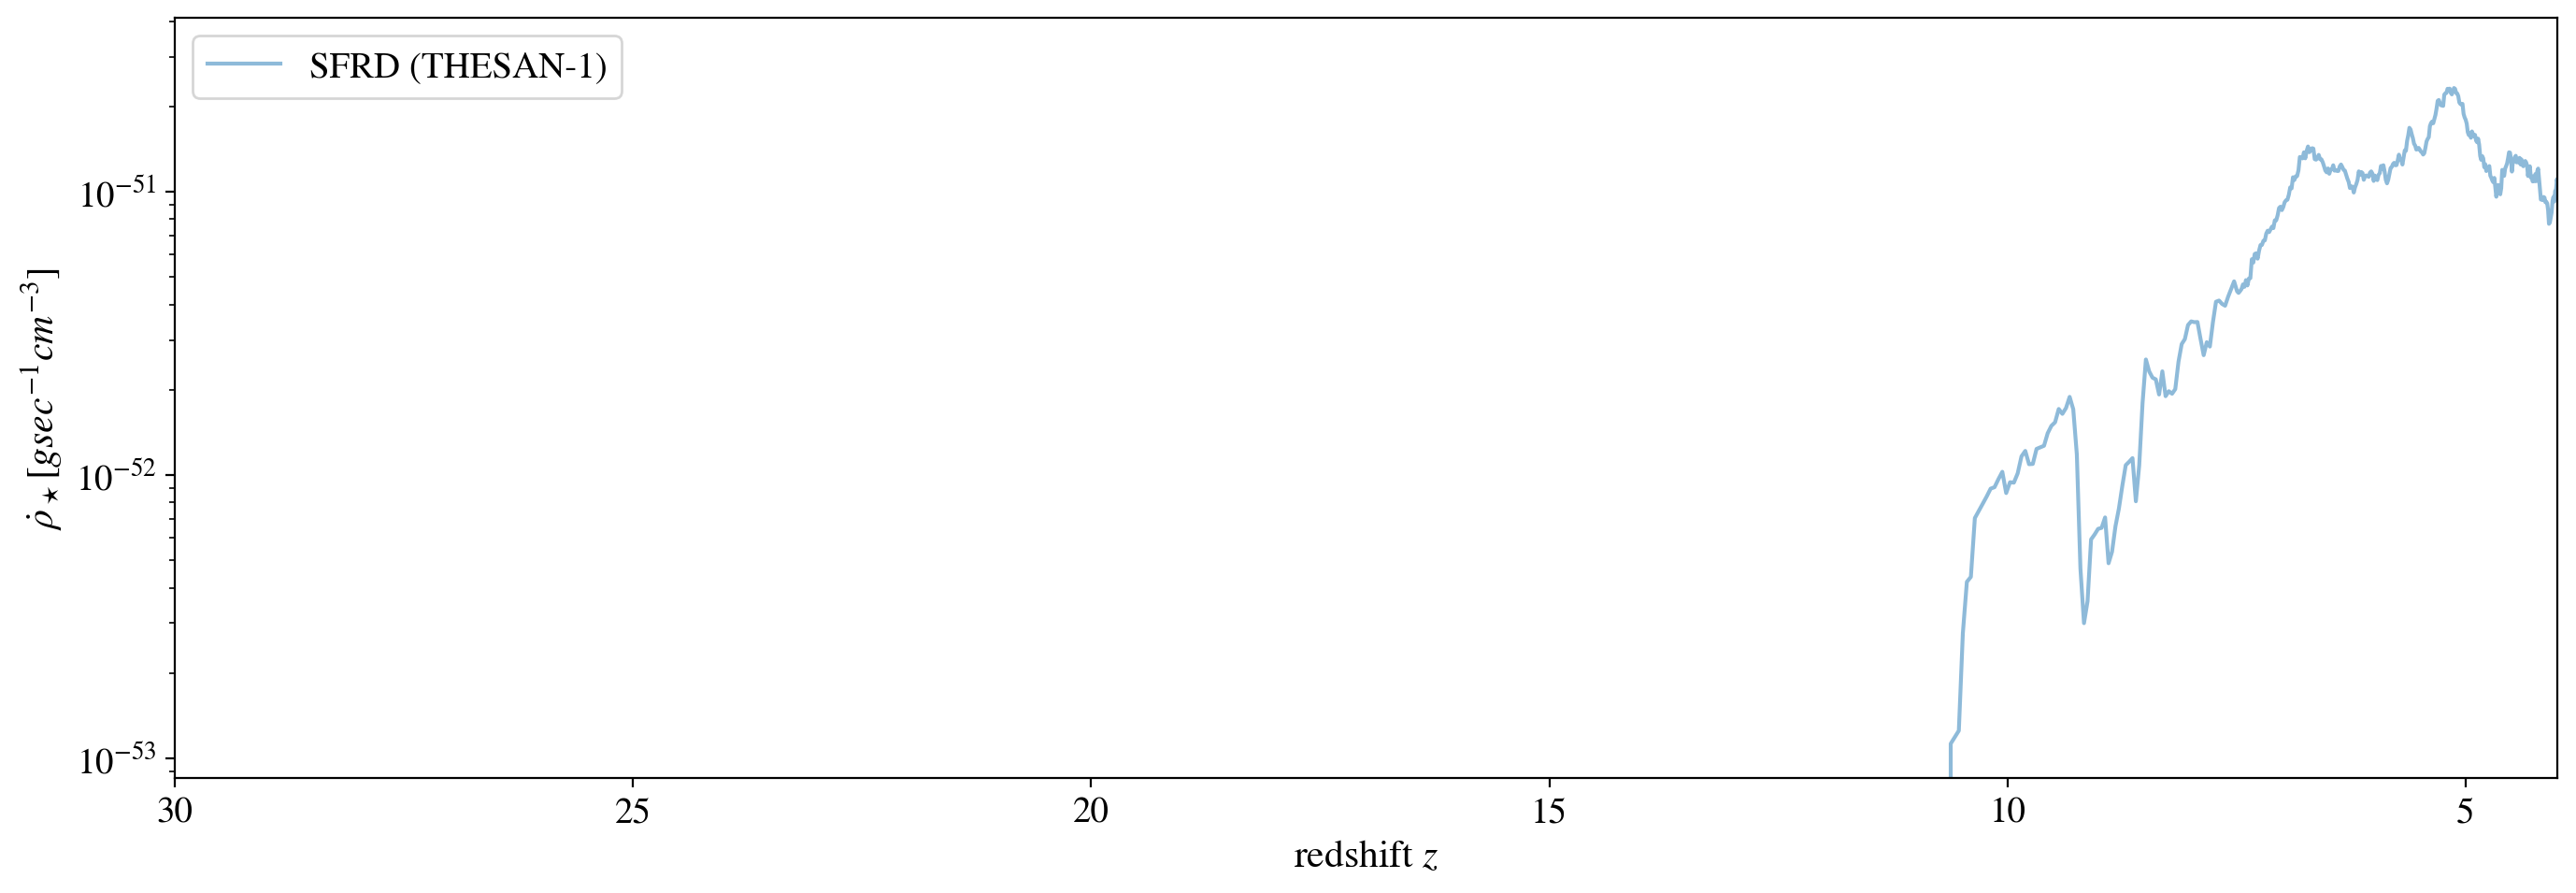

In [13]:
plt.figure(figsize=(14,5))
#plt.plot(df["redshift"], T_S_array, label='Spin temperature')


#plt.plot(df_sfr_xl["redshift"], df_sfr_xl["SFRD"]*1.5*((1+df_sfr_xl["redshift"])/10)**2.0, label="Boosted SFRD (THESAN-XL)", alpha=0.5)
#plt.plot(df_sfr_xl["redshift"], df_sfr_xl["SFRD"], label="SFRD (THESAN-XL)", alpha=0.5)
plt.plot(df_xl_z4_cell["redshift"], df_xl_z4_cell["SFRD"], label="SFRD (THESAN-1)", alpha=0.5)
plt.xlim(4,30)
plt.xlabel(r"redshift $z$", fontsize=15)
plt.ylabel(r"$\dot{\rho}_\star [g sec^{-1} cm^{-3}]$", fontsize=15)
plt.legend()
plt.yscale("log")
# Reverse X-axis
plt.gca().invert_xaxis()

plt.tight_layout()
plt.show()

In [ ]:
df_sfr_xl["redshift"][4664:], df_sfr_xl["SFRD"][4664:]*3

(4664      16.097404
 4665      16.096384
 4666      16.095364
 4667      16.094344
 4668      16.093325
             ...    
 321113     4.752995
 321114     4.752985
 321115     4.752975
 321116     4.752965
 321117     4.752952
 Name: redshift, Length: 316454, dtype: float64,
 4664      8.311084e-55
 4665      8.030470e-53
 4666      8.231174e-55
 4667      1.521008e-51
 4668      8.321020e-55
               ...     
 321113    1.697470e-48
 321114    1.237115e-51
 321115    7.848350e-50
 321116    1.231096e-51
 321117    1.268757e-47
 Name: SFRD, Length: 316454, dtype: float64)

In [ ]:
df_sfr_1["redshift"][1:], df_sfr_1["SFRD"][1:]

(1         16.097910
 2         16.093538
 3         16.089165
 4         16.084794
 5         16.082611
             ...    
 298224     5.445234
 298225     5.445230
 298226     5.445222
 298227     5.445218
 298228     5.445209
 Name: redshift, Length: 298228, dtype: float64,
 1         7.008760e-55
 2         7.767843e-56
 3         1.014201e-52
 4         4.467481e-55
 5         1.880620e-56
               ...     
 298224    7.861736e-54
 298225    4.869777e-49
 298226    8.134304e-54
 298227    7.074455e-51
 298228    8.126847e-54
 Name: SFRD, Length: 298228, dtype: float64)